# Clasificación de enfermedades en hojas de tomate con un Perceptrón Multicapa

**Asignatura:** TLY1102 — Técnicas Avanzadas de Machine Learning I
**Evaluación:** Parcial N°1 — Presentación y defensa técnica
**Dataset:** PlantVillage (Kaggle: `emmarex/plantdisease`)

---

### Flujo de trabajo

| # | Etapa | Qué se resuelve |
|---|-------|-----------------|
| 1 | **Problema** | Qué se clasifica, por qué importa y cuál es la variante del grupo |
| 2 | **Datos** | Carga, conteo por clase, calidad y exploración visual (EDA) |
| 3 | **Preprocesamiento** | Redimensionado, normalización y partición estratificada |
| 4 | **MLP** | Arquitectura, activaciones, función de salida, pérdida y optimizador |
| 5 | **Entrenamiento** | Curvas de pérdida y accuracy, diagnóstico de convergencia |
| 6 | **Evaluación** | Accuracy, Precision, Recall, F1 y matriz de confusión |
| 7 | **Errores** | Aciertos, fallos, clases confundidas y límites del MLP en imágenes |
| 8 | **Conclusiones** | Hallazgos, decisiones de diseño y mejoras futuras |

### Variante definida por el grupo

Para diferenciar el trabajo de otros grupos se fijan estas decisiones:

- **5 clases** del cultivo tomate (no las 38 del dataset completo).
- **400 imágenes por clase** como máximo → 2.000 imágenes en total, muestreadas al azar.
- **Semilla 1102** en todo el proceso (muestreo, particiones, inicialización).
- **Resolución 64 × 64 px** en RGB → 12.288 valores de entrada por imagen.
- **Partición estratificada 70 / 15 / 15** en entrenamiento, validación y prueba.

> Cada decisión queda registrada en la constante correspondiente para que el
> notebook sea reproducible de principio a fin.

## 0. Configuración del entorno

Diseñado para ejecutarse en **Google Colab** (también funciona en local). Todas
las librerías que se usan vienen preinstaladas en Colab, así que no hace falta
instalar nada.

Se importa todo al inicio y se fija la semilla antes de cualquier operación
aleatoria, de modo que dos ejecuciones distintas entreguen los mismos resultados.

In [1]:
# Solo se instala lo que falte (en Colab normalmente no falta nada).
# Si esta celda no imprime nada, el entorno ya estaba completo.
import importlib

for paquete in ["tensorflow", "sklearn", "seaborn", "pandas", "matplotlib", "PIL"]:
    if importlib.util.find_spec(paquete) is None:
        nombre_pip = {"sklearn": "scikit-learn", "PIL": "pillow"}.get(paquete, paquete)
        print(f"Instalando {nombre_pip}...")
        %pip install -q {nombre_pip}

In [2]:
import os
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout, BatchNormalization, Activation,
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ---- Semilla única para todo el proyecto (variante del grupo) --------------
SEED = 1102
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("TensorFlow:", tf.__version__)
print("Semilla fijada en:", SEED)

/Users/bastian/Documents/Proyectos/MLp/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow: 2.20.0
Semilla fijada en: 1102


### Montaje de Google Drive

En Colab el dataset se lee desde Drive. **Antes de ejecutar**, sube
`PlantVillage.zip` (o la carpeta ya descomprimida) a tu unidad en:

```text
Mi unidad/PlantVillage_MLP/PlantVillage.zip
```

Si el notebook se ejecuta fuera de Colab, esta celda no hace nada y se usa la
carpeta local `data/`.

In [3]:
IN_COLAB = importlib.util.find_spec("google.colab") is not None
print("Entorno:", "Google Colab" if IN_COLAB else "local")

DRIVE_ROOT = None

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/PlantVillage_MLP")
    DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
    print("Carpeta de trabajo en Drive:", DRIVE_ROOT)

Entorno: local


### Localización del dataset

Se busca el dataset en este orden:

1. Una carpeta ya descomprimida (en `/content` o en Drive, según el entorno).
2. Un `PlantVillage.zip` en Drive o en el proyecto → se descomprime solo las
   **cinco clases de tomate** que usa la variante, no las 15 del archivo completo.
3. La carpeta local `data/PlantVillage` (ejecución fuera de Colab).

Extraer solo lo necesario evita copiar ~40.000 archivos: son unos 7.500, y la
descompresión baja de varios minutos a segundos.

In [4]:
import zipfile

IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

# Las cinco clases de la variante. Se declara aquí porque la extracción
# selectiva del zip las necesita antes de la sección 2.
SELECTED_CLASSES = [
    "Tomato_healthy",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Bacterial_spot",
]


def es_raiz_valida(directorio):
    """True si el directorio contiene las cinco clases con imágenes dentro."""
    directorio = Path(directorio)

    if not directorio.is_dir():
        return False

    for clase in SELECTED_CLASSES:
        carpeta = directorio / clase

        if not carpeta.is_dir():
            return False
        if not any(p.suffix.lower() in IMAGE_EXTS for p in carpeta.iterdir()):
            return False

    return True


def extraer_clases(ruta_zip, destino):
    """Descomprime del zip solo las imágenes de las clases seleccionadas."""
    destino = Path(destino)
    extraidas = 0

    with zipfile.ZipFile(ruta_zip) as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue

            partes = Path(info.filename).parts

            # El zip de Kaggle trae el contenido duplicado en dos niveles
            # ('PlantVillage/...' y 'plantvillage/PlantVillage/...'), así que
            # se identifica la clase por el nombre de la carpeta contenedora
            # y se ignora el resto de la ruta.
            if len(partes) < 2 or partes[-2] not in SELECTED_CLASSES:
                continue
            if Path(info.filename).suffix.lower() not in IMAGE_EXTS:
                continue

            salida = destino / partes[-2] / partes[-1]

            if salida.exists():      # evita reescribir el duplicado del zip
                continue

            salida.parent.mkdir(parents=True, exist_ok=True)
            salida.write_bytes(zf.read(info))
            extraidas += 1

    print(f"Imágenes extraídas: {extraidas}")
    return destino

In [5]:
def find_project_root(start=None):
    """Sube directorios hasta encontrar la carpeta que contiene 'data'."""
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir():
            return candidate

    return current


PROJECT_ROOT = find_project_root()

# --- 1. Carpetas ya descomprimidas ----------------------------------------
carpetas_candidatas = [
    Path("/content/plantvillage/PlantVillage"),
    Path("/content/plantvillage"),
    PROJECT_ROOT / "data" / "PlantVillage",
    PROJECT_ROOT / "data",
]

if DRIVE_ROOT is not None:
    carpetas_candidatas = [
        DRIVE_ROOT / "PlantVillage" / "PlantVillage",
        DRIVE_ROOT / "PlantVillage",
    ] + carpetas_candidatas

# Cualquier carpeta subida o descomprimida a mano directo en la sesión de
# Colab (panel de archivos): no se puede predecir su nombre, así que se
# revisa cada subcarpeta de /content (y un nivel más adentro, por si el zip
# de Kaggle trae todo anidado dos veces).
if IN_COLAB and Path("/content").is_dir():
    for p in sorted(Path("/content").iterdir()):
        if p.is_dir() and p.name != "drive":
            carpetas_candidatas += [p, p / "PlantVillage"]

DATA_ROOT = next((c for c in carpetas_candidatas if es_raiz_valida(c)), None)

# --- 2. Si no hay carpeta, buscar un zip y extraer las cinco clases -------
if DATA_ROOT is None:
    zips_candidatos = [
        PROJECT_ROOT / "data" / "raw" / "PlantVillage Dataset.zip",
        PROJECT_ROOT / "data" / "raw" / "PlantVillage.zip",
        PROJECT_ROOT / "PlantVillage.zip",
    ]

    if DRIVE_ROOT is not None:
        zips_candidatos = [
            DRIVE_ROOT / "PlantVillage.zip",
            DRIVE_ROOT / "PlantVillage Dataset.zip",
        ] + zips_candidatos

    # Cualquier .zip subido directo a la sesión de Colab (panel de archivos,
    # ícono de carpeta): tampoco se puede predecir el nombre, así que se
    # revisan todos los .zip sueltos en /content.
    if IN_COLAB and Path("/content").is_dir():
        zips_candidatos += sorted(Path("/content").glob("*.zip"))

    zip_encontrado = next((z for z in zips_candidatos if z.is_file()), None)

    assert zip_encontrado is not None, (
        "No se encontró el dataset.\n"
        "En Colab: sube PlantVillage.zip a la sesión (panel de archivos) o a "
        "'Mi unidad/PlantVillage_MLP/' en Drive.\n"
        "En local: deja el zip en data/raw/ o la carpeta en data/PlantVillage/.\n"
        f"Rutas revisadas: {[str(z) for z in zips_candidatos]}"
    )

    print("Descomprimiendo desde:", zip_encontrado)
    # El zip está en Drive si su ruta cae bajo /content/drive; si no, se subió
    # directo a la sesión (panel de archivos) y no sobrevive un reinicio.
    if IN_COLAB and "/content/drive/" not in str(zip_encontrado):
        print(
            "Nota: este archivo está en la sesión de Colab, no en Drive.\n"
            "Funciona, pero se borra si la sesión se desconecta o reinicia: "
            "tendrías que volver a subirlo. Para que quede guardado entre "
            "sesiones, súbelo a Drive en 'Mi unidad/PlantVillage_MLP/' en su lugar."
        )
    destino = (
        Path("/content/plantvillage") if IN_COLAB
        else PROJECT_ROOT / "data" / "PlantVillage"
    )
    DATA_ROOT = extraer_clases(zip_encontrado, destino)

assert es_raiz_valida(DATA_ROOT), (
    f"La carpeta {DATA_ROOT} no contiene las cinco clases esperadas."
)

# --- 3. Carpetas de salida ------------------------------------------------
# En Colab se escriben en Drive para que no se pierdan al cerrar la sesión.
SALIDA_BASE = DRIVE_ROOT if DRIVE_ROOT is not None else PROJECT_ROOT
IMAGES_DIR = SALIDA_BASE / "images"
MODELS_DIR = SALIDA_BASE / "models"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("\nDataset   :", DATA_ROOT)
print("Figuras   :", IMAGES_DIR)
print("Modelos   :", MODELS_DIR)


def save_fig(nombre):
    """Guarda la figura actual para reutilizarla en el informe."""
    destino = IMAGES_DIR / nombre
    plt.savefig(destino, dpi=150, bbox_inches="tight")
    print("Figura guardada:", destino.name)


Dataset   : /Users/bastian/Documents/Proyectos/MLp/data/PlantVillage
Figuras   : /Users/bastian/Documents/Proyectos/MLp/images
Modelos   : /Users/bastian/Documents/Proyectos/MLp/models


## 1. Problema

### Contexto de negocio

El tomate es uno de los cultivos de mayor valor comercial y también uno de los
más vulnerables a enfermedades foliares. Hoy el diagnóstico en campo depende de
la inspección visual de un agrónomo: es lento, no escala a cientos de hectáreas
y su precisión varía según la experiencia de quien revisa. Cuando una infección
como el *tizón tardío* se detecta tarde, puede arrasar un cultivo completo en
pocos días.

**Oportunidad:** si una fotografía tomada con un teléfono permite reconocer la
enfermedad, el productor puede priorizar qué sectores inspeccionar y aplicar
tratamiento dirigido en lugar de fumigar todo el campo por precaución.

### Problema de clasificación

Dada la imagen de una hoja de tomate, asignarla a **una de cinco categorías**:
una sana y cuatro enfermedades distintas. Es un problema de **clasificación
supervisada multiclase** (5 clases mutuamente excluyentes) sobre datos de imagen.

| Clase | Naturaleza | Señal visual característica |
|-------|-----------|------------------------------|
| `Tomato_healthy` | Sana | Hoja verde uniforme, sin lesiones |
| `Tomato_Early_blight` | Hongo | Manchas concéntricas tipo diana |
| `Tomato_Late_blight` | Hongo | Lesiones irregulares café con halo pálido |
| `Tomato_Leaf_Mold` | Hongo | Manchas amarillas difusas en el haz |
| `Tomato_Bacterial_spot` | Bacteria | Puntos pequeños, oscuros y numerosos |

### Objetivo del proyecto

Construir y evaluar críticamente un **Perceptrón Multicapa (MLP)** que sirva de
*modelo base* para esta tarea, documentando el flujo completo de aprendizaje
supervisado y — punto central de esta evaluación — **identificando las
limitaciones estructurales del MLP frente a imágenes**, que justificarán el paso
a arquitecturas convolucionales en la siguiente unidad.

> El objetivo **no** es maximizar el accuracy. Es comprender el flujo de trabajo
> y argumentar técnicamente cada decisión.

### Objetivos específicos

1. Caracterizar el subconjunto de datos y verificar su calidad (EDA).
2. Preprocesar las imágenes de forma coherente con la entrada que exige un MLP.
3. Diseñar una arquitectura MLP justificando capas, activaciones e hiperparámetros.
4. Entrenar con validación y diagnosticar convergencia, overfitting y underfitting.
5. Evaluar con Accuracy, Precision, Recall, F1 y matriz de confusión.
6. Auditar los errores e identificar qué clases se confunden y por qué.

### KPIs

Se distingue entre la métrica que guía el entrenamiento y los indicadores que
responden a la pregunta de negocio.

| KPI | Definición | Meta | Por qué este umbral |
|-----|-----------|------|---------------------|
| **Accuracy (test)** | % de hojas bien clasificadas | ≥ 60 % | Un clasificador al azar entre 5 clases balanceadas acierta 20 %; triplicar ese valor demuestra que la red aprendió señal real |
| **F1-score macro** | Media armónica de precision y recall, promediada por clase | ≥ 0,60 | Promedia por clase sin ponderar por frecuencia: una clase ignorada por el modelo hunde el indicador aunque el accuracy se vea bien |
| **Recall de clases enfermas** | Enfermas detectadas sobre enfermas reales | ≥ 0,60 | Un falso negativo (enferma clasificada como sana) es el error costoso: la planta queda sin tratamiento y contagia al resto |
| **Brecha de generalización** | Accuracy de entrenamiento − accuracy de prueba | ≤ 0,15 | Mide memorización; una brecha amplia indica que el modelo no sirve con hojas nuevas |

**Por qué el recall pesa más que la precision en este problema:** un falso
positivo hace que el agrónomo revise una planta sana — cuesta unos minutos. Un
falso negativo deja una planta enferma sin tratar y sigue contagiando. Los dos
errores no son simétricos, y por eso el KPI de recall se reporta separado por
clase y no solo en el promedio.

### Metodología: CRISP-DM

| Fase CRISP-DM | Dónde se resuelve en este notebook |
|---------------|-----------------------------------|
| Comprensión del negocio | Sección 1 (problema, objetivos, KPIs) |
| Comprensión de los datos | Sección 2 (conteos, calidad, EDA visual) |
| Preparación de los datos | Sección 3 (redimensionado, normalización, partición) |
| Modelado | Sección 4 (arquitectura MLP) y 5 (entrenamiento) |
| Evaluación | Secciones 6 y 7 (métricas y auditoría de errores) |
| Despliegue | Sección 8 (se discute como trabajo futuro, fuera del alcance) |

### Consideraciones éticas

- **Sesgo de captura:** todas las imágenes de PlantVillage fueron tomadas en
  condiciones controladas, con hoja arrancada y fondo uniforme. El modelo no ha
  visto hojas en la planta, con sombra, tierra o lluvia. Usarlo en campo sin
  reentrenar sobrestimaría su desempeño.
- **Decisión asistida, no automática:** la salida debe orientar la inspección
  humana, no gatillar la aplicación de agroquímicos por sí sola. Un falso
  positivo masivo implicaría fumigación innecesaria, con costo económico y
  ambiental.
- **Alcance declarado:** el modelo distingue cinco condiciones de *tomate*. Ante
  una especie u otra enfermedad responderá con una de las cinco etiquetas que
  conoce, con confianza alta y sin advertir nada. La cobertura limitada debe
  informarse a quien lo use.

## 2. Datos

### 2.1 Fuente

**PlantVillage** es un conjunto público de hojas de cultivo fotografiadas en
laboratorio sobre fondo uniforme, con etiqueta verificada por especialistas.

| Atributo | Valor |
|----------|-------|
| Origen | Kaggle — `emmarex/plantdisease` |
| Volumen total | > 20.000 imágenes, 15 clases (pimiento, papa, tomate) |
| Formato | JPG, RGB (3 canales), 256 × 256 px |
| Etiqueta | Carpeta contenedora (una por clase) |
| Licencia | Uso público para investigación |

**Por qué este dataset:** está etiquetado y balanceado, tiene volumen suficiente
para entrenar sin aumento de datos, y su señal visual es de textura y color —
justamente el tipo de patrón que permite mostrar dónde un MLP alcanza su techo.

In [6]:
def list_images(directory):
    return sorted(
        path for path in Path(directory).iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS
    )


# Inventario completo de lo que hay disponible en disco
inventario = pd.Series({
    carpeta.name: len(list_images(carpeta))
    for carpeta in sorted(DATA_ROOT.iterdir())
    if carpeta.is_dir()
}, name="imagenes").sort_values(ascending=False)

print("Clases disponibles:", len(inventario))
print("Imágenes disponibles:", int(inventario.sum()))
inventario.to_frame()

Clases disponibles: 5
Imágenes disponibles: 7579


,imagenes
Tomato_Bacterial_spot,2127
Tomato_Late_blight,1909
Tomato_healthy,1591
Tomato_Early_blight,1000
Tomato_Leaf_Mold,952


### 2.2 Selección de la variante

Se aplican aquí las tres decisiones que definen la variante del grupo: qué clases,
cuántas imágenes por clase y con qué semilla se muestrean.

In [7]:
# SELECTED_CLASSES se declaró en la sección 0 porque la extracción del zip
# la necesita. Se muestra aquí para dejar la variante a la vista:
print("Clases de la variante:")
for c in SELECTED_CLASSES:
    print("  -", c)

MAX_IMAGES_PER_CLASS = 400   # variante del grupo: subconjunto acotado

# Etiqueta entera por clase: el orden de SELECTED_CLASSES define el índice,
# y ese mismo orden se reutiliza en la matriz de confusión.
LABEL_TO_ID = {clase: i for i, clase in enumerate(SELECTED_CLASSES)}
ID_TO_LABEL = {i: clase for clase, i in LABEL_TO_ID.items()}

partes = []

for clase in SELECTED_CLASSES:
    rutas = list_images(DATA_ROOT / clase)
    disponibles = pd.DataFrame({"path": [str(p) for p in rutas]})
    disponibles["label"] = clase

    # Muestreo aleatorio reproducible; si una clase tuviera menos de 400
    # imágenes se toman todas las que haya.
    n = min(MAX_IMAGES_PER_CLASS, len(disponibles))
    partes.append(disponibles.sample(n=n, random_state=SEED))

    print(f"{clase:<26} disponibles: {len(rutas):>5}   seleccionadas: {n:>4}")

df = pd.concat(partes, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # mezclar
df["label_id"] = df["label"].map(LABEL_TO_ID).astype("int32")

print("\nTotal de imágenes en el estudio:", len(df))
df.head()

Clases de la variante:
  - Tomato_healthy
  - Tomato_Early_blight
  - Tomato_Late_blight
  - Tomato_Leaf_Mold
  - Tomato_Bacterial_spot
Tomato_healthy             disponibles:  1591   seleccionadas:  400
Tomato_Early_blight        disponibles:  1000   seleccionadas:  400
Tomato_Late_blight         disponibles:  1909   seleccionadas:  400
Tomato_Leaf_Mold           disponibles:   952   seleccionadas:  400
Tomato_Bacterial_spot      disponibles:  2127   seleccionadas:  400

Total de imágenes en el estudio: 2000


,path,label,label_id
0,/Users/bastian/Documents/Proyectos/MLp/data/Pl...,Tomato_Early_blight,1
1,/Users/bastian/Documents/Proyectos/MLp/data/Pl...,Tomato_healthy,0
2,/Users/bastian/Documents/Proyectos/MLp/data/Pl...,Tomato_Late_blight,2
3,/Users/bastian/Documents/Proyectos/MLp/data/Pl...,Tomato_Late_blight,2
4,/Users/bastian/Documents/Proyectos/MLp/data/Pl...,Tomato_Late_blight,2


### 2.3 Distribución de clases

Antes de modelar hay que saber si las clases están balanceadas: de eso depende si
el accuracy es una métrica confiable o si hay que apoyarse en F1 y en el recall
por clase.

Figura guardada: 02_distribucion_clases.png


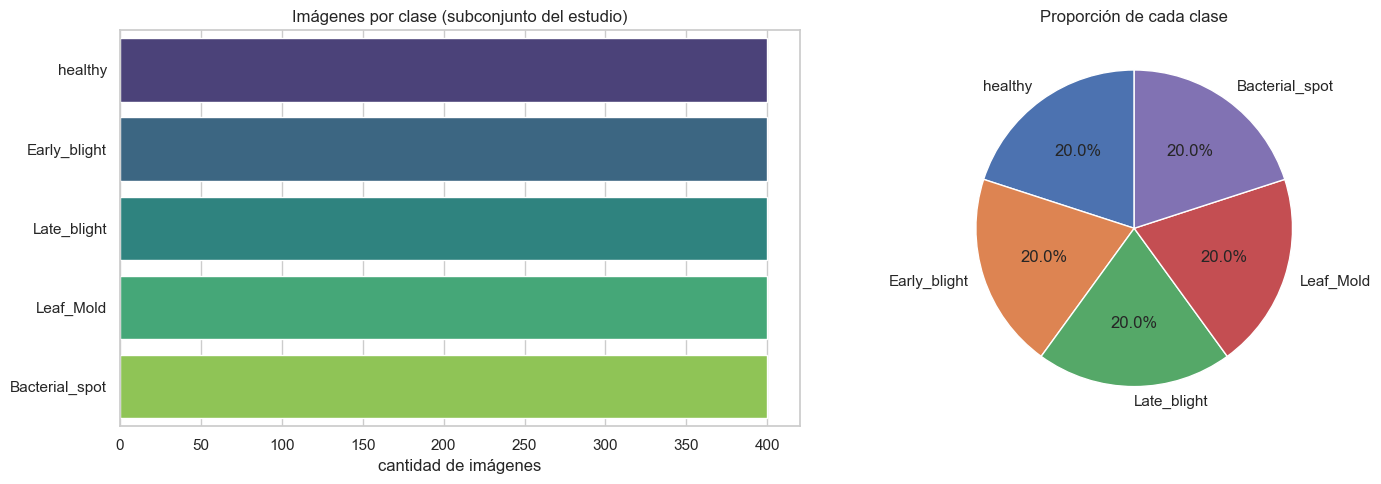

Razón de desbalance (máx/mín): 1.00
Conjunto balanceado


In [8]:
conteo = df["label"].value_counts().reindex(SELECTED_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    x=conteo.values,
    y=[c.replace("Tomato_", "") for c in conteo.index],
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Imágenes por clase (subconjunto del estudio)")
axes[0].set_xlabel("cantidad de imágenes")

axes[1].pie(
    conteo.values,
    labels=[c.replace("Tomato_", "") for c in conteo.index],
    autopct="%1.1f%%",
    startangle=90,
)
axes[1].set_title("Proporción de cada clase")

plt.tight_layout()
save_fig("02_distribucion_clases.png")
plt.show()

desbalance = conteo.max() / conteo.min()
print(f"Razón de desbalance (máx/mín): {desbalance:.2f}")
print("Conjunto balanceado" if desbalance < 1.5 else "Conjunto desbalanceado")

**Lectura:** el muestreo tope de 400 por clase dejó las cinco clases con el mismo
número de imágenes, así que el conjunto quedó perfectamente balanceado. Dos
consecuencias prácticas:

1. El **accuracy es interpretable**: no puede inflarse prediciendo siempre la
   clase mayoritaria, porque no hay clase mayoritaria.
2. La **línea base al azar es 20 %** (1/5). Cualquier resultado cercano a ese
   valor significa que la red no aprendió nada.

Aun así se reportan Precision, Recall y F1 por clase, porque el accuracy global
puede esconder que una clase específica se está clasificando mal.

### 2.4 Control de calidad

Se revisan las imágenes seleccionadas para descartar archivos corruptos,
resoluciones inconsistentes o imágenes en escala de grises que romperían el
supuesto de 3 canales.

In [9]:
registros = []

for fila in df.itertuples():
    try:
        with Image.open(fila.path) as img:
            registros.append({
                "label": fila.label,
                "ancho": img.width,
                "alto": img.height,
                "modo": img.mode,
                "corrupta": False,
            })
    except Exception:
        registros.append({
            "label": fila.label,
            "ancho": np.nan,
            "alto": np.nan,
            "modo": None,
            "corrupta": True,
        })

calidad = pd.DataFrame(registros)

print("Imágenes corruptas:", int(calidad["corrupta"].sum()))
print("Modos de color:", calidad["modo"].value_counts().to_dict())
print("Resoluciones distintas:",
      calidad.groupby(["ancho", "alto"]).size().to_dict())
print("\nValores duplicados de ruta:", int(df["path"].duplicated().sum()))
calidad.describe()

Imágenes corruptas: 0
Modos de color: {'RGB': 2000}
Resoluciones distintas: {(256, 256): 2000}

Valores duplicados de ruta: 0


,ancho,alto
count,2000.0,2000.0
mean,256.0,256.0
std,0.0,0.0
min,256.0,256.0
25%,256.0,256.0
50%,256.0,256.0
75%,256.0,256.0
max,256.0,256.0


**Lectura:** no hay archivos corruptos, todas las imágenes son RGB y comparten la
resolución 256 × 256. El conjunto está limpio, así que **no se requiere imputación
ni descarte de registros**. Esto no es casualidad: PlantVillage se construyó en
laboratorio con protocolo fijo, y esa uniformidad es precisamente lo que después
limitará la generalización del modelo a fotos reales de campo.

### 2.5 Exploración visual

Ver las imágenes es parte del análisis, no decoración: permite anticipar qué
clases van a confundirse antes de entrenar.

Figura guardada: 02_ejemplos_por_clase.png


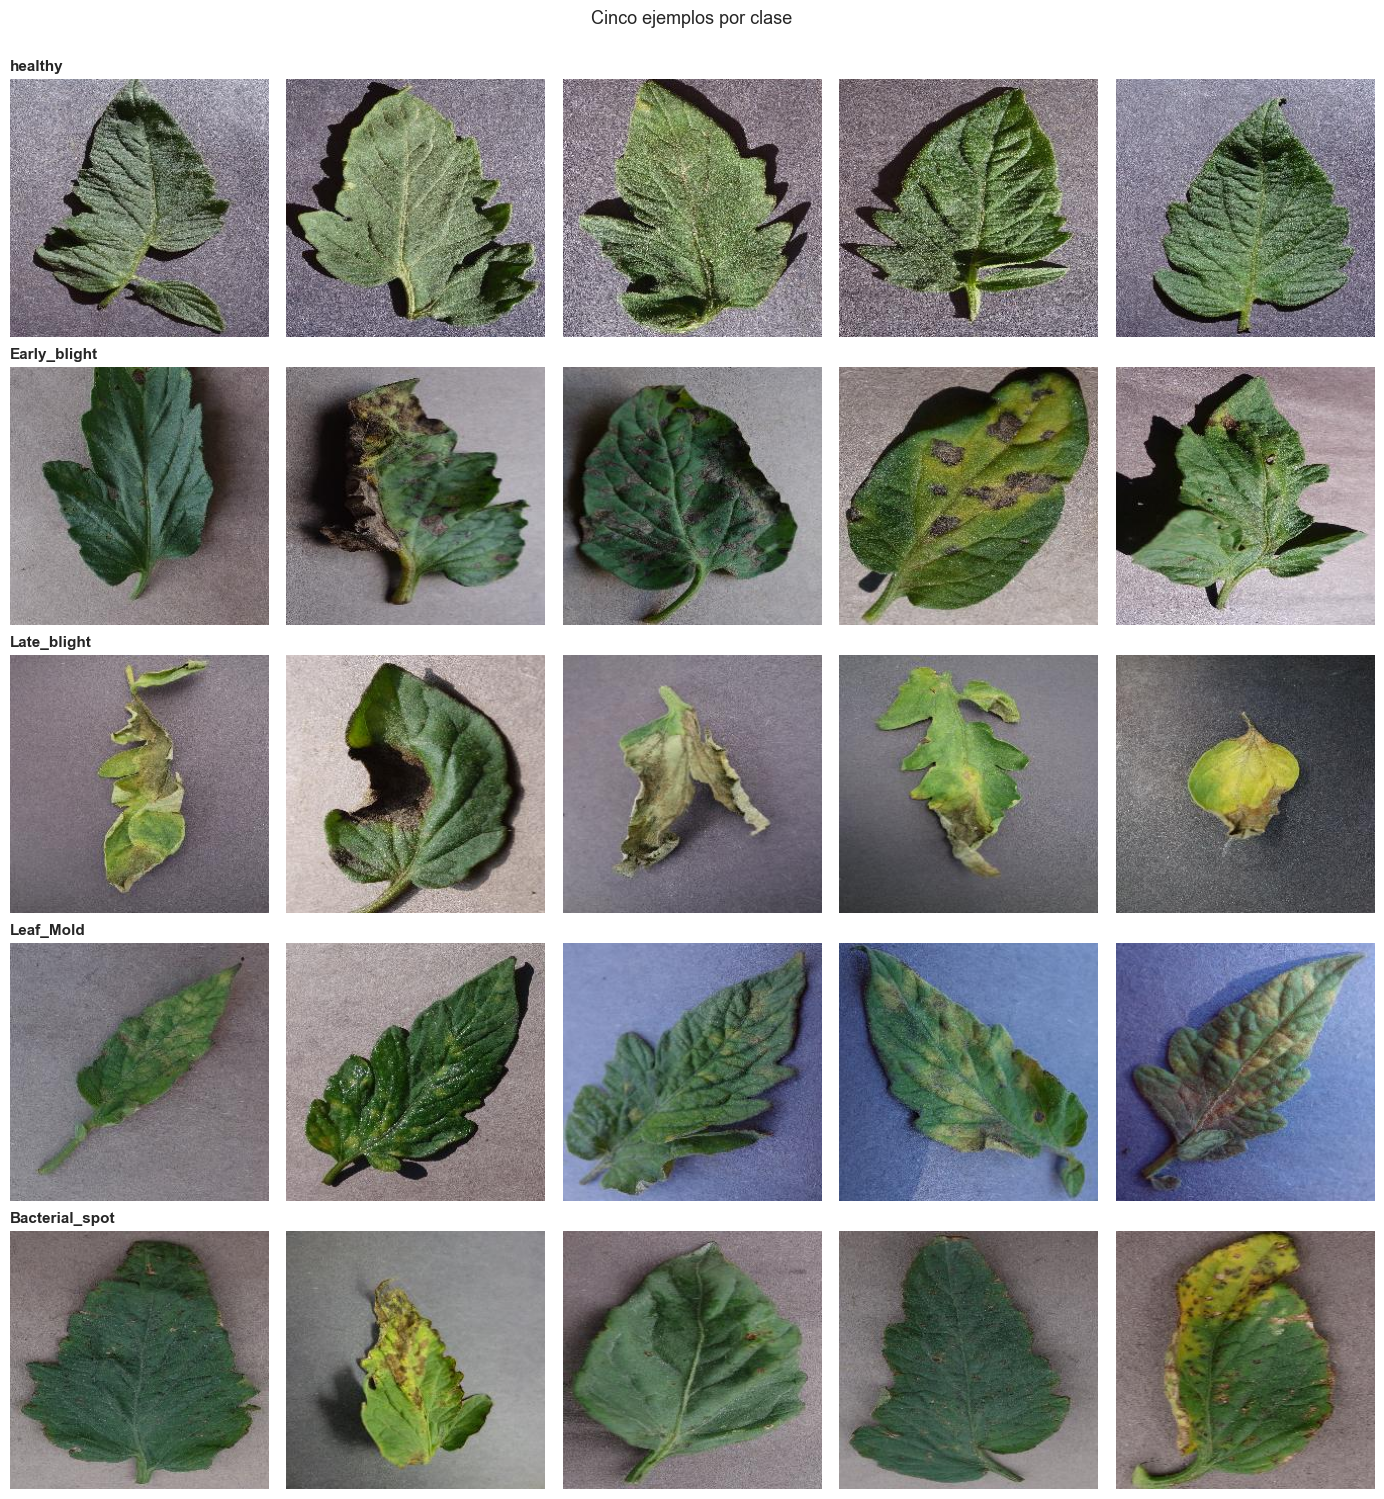

In [10]:
fig, axes = plt.subplots(
    len(SELECTED_CLASSES), 5,
    figsize=(14, 3 * len(SELECTED_CLASSES)),
)

for i, clase in enumerate(SELECTED_CLASSES):
    muestras = df[df["label"] == clase].head(5)

    for j, fila in enumerate(muestras.itertuples()):
        with Image.open(fila.path) as img:
            axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if j == 0:
            axes[i, j].set_title(
                clase.replace("Tomato_", ""),
                loc="left", fontsize=11, fontweight="bold",
            )

plt.suptitle("Cinco ejemplos por clase", y=1.0, fontsize=13)
plt.tight_layout()
save_fig("02_ejemplos_por_clase.png")
plt.show()

### 2.6 Color promedio por clase

Un MLP sobre píxeles planos no detecta formas: lo que puede aprovechar son
diferencias globales de color e intensidad. Conviene medir cuánta señal hay ahí.

Figura guardada: 02_color_por_clase.png


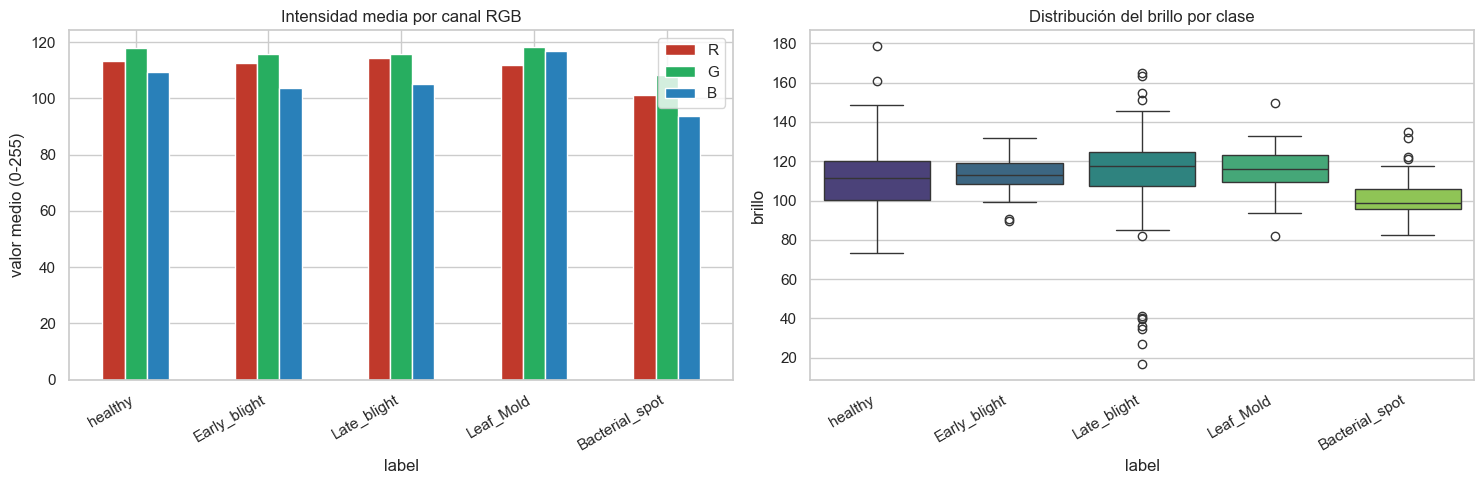

,R,G,B,brillo
label,,,,
Tomato_healthy,113.500000,117.800003,109.400002,113.599998
Tomato_Early_blight,112.500000,115.699997,103.599998,110.599998
Tomato_Late_blight,114.400002,115.800003,105.000000,111.699997
Tomato_Leaf_Mold,111.900002,118.300003,116.800003,115.599998
Tomato_Bacterial_spot,101.400002,108.400002,93.900002,101.199997


In [11]:
def color_promedio(ruta, tamano=(64, 64)):
    with Image.open(ruta) as img:
        arr = np.asarray(img.convert("RGB").resize(tamano), dtype=np.float32)
    return arr.reshape(-1, 3).mean(axis=0)


# Se usa una submuestra por clase: suficiente para estimar la tendencia
muestra = df.groupby("label", group_keys=False).head(80)
canales = np.stack([color_promedio(p) for p in muestra["path"]])

color_df = pd.DataFrame(canales, columns=["R", "G", "B"])
color_df["label"] = muestra["label"].values
color_df["brillo"] = color_df[["R", "G", "B"]].mean(axis=1)

resumen_color = (
    color_df.groupby("label")[["R", "G", "B", "brillo"]]
    .mean()
    .reindex(SELECTED_CLASSES)
    .round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

resumen_color[["R", "G", "B"]].plot(
    kind="bar", ax=axes[0], color=["#c0392b", "#27ae60", "#2980b9"],
)
axes[0].set_title("Intensidad media por canal RGB")
axes[0].set_ylabel("valor medio (0-255)")
axes[0].set_xticklabels(
    [c.replace("Tomato_", "") for c in resumen_color.index],
    rotation=30, ha="right",
)

sns.boxplot(
    data=color_df, x="label", y="brillo", ax=axes[1], palette="viridis",
)
axes[1].set_title("Distribución del brillo por clase")
axes[1].set_xticklabels(
    [c.replace("Tomato_", "") for c in SELECTED_CLASSES],
    rotation=30, ha="right",
)

plt.tight_layout()
save_fig("02_color_por_clase.png")
plt.show()

resumen_color

**Lectura:** las clases **no** se separan de forma homogénea por color global.

- `Bacterial_spot` y `Leaf_Mold` sí tienen una firma de color propia: la primera
  es notablemente más oscura que el resto, la segunda destaca por su canal azul.
- `Early_blight` y `Late_blight` tienen el perfil de color **más parecido entre
  sí de todo el conjunto** (sus medias de brillo son casi idénticas y los
  boxplots se solapan casi por completo). Ambas son enfermedades fúngicas que
  producen lesiones café sobre tejido verde; lo que las diferencia es la *forma*
  de la lesión —anillos concéntricos frente a manchas irregulares—, no el color.
- `healthy` es un caso aparte: no tiene lesión que darle una firma de color
  particular, así que su color medio queda en un punto intermedio del grupo. Su
  rasgo distintivo no es cromático sino la **ausencia de cualquier textura
  anómala** en toda la hoja — una propiedad más difícil de anticipar solo con
  este gráfico.

**Predicción verificable:** si un MLP sobre píxeles planos solo puede explotar
estadísticos globales de color, el par `Early_blight`/`Late_blight` —el más
parecido en color— debería ser el que más se confunde entre sí, mientras que
`Bacterial_spot` y `Leaf_Mold` deberían clasificarse mejor por tener firma
propia. Qué pasa con `healthy` queda abierto: depende de si el modelo logra
capturar la ausencia de textura como patrón, algo que ni este gráfico ni el
razonamiento de esta sección permiten anticipar. Esta predicción se contrasta
contra la matriz de confusión real en la **sección 7.5**.

La razón de fondo por la que el color pesa tanto es que `Flatten()` destruye la
vecindad entre píxeles, y con ella la noción de "anillo concéntrico". La red
queda con 12.288 valores sin estructura espacial, y lo único que le resulta
fácil de explotar es un promedio global como el color.

## 3. Preprocesamiento

Cuatro transformaciones, cada una con su justificación técnica.

### 3.1 Partición estratificada

Se separa **antes** de cualquier ajuste, para que ninguna información del conjunto
de prueba influya en el entrenamiento (evitar *data leakage*).

- **70 % entrenamiento** — ajustar los pesos.
- **15 % validación** — decidir cuándo detener y comparar configuraciones.
- **15 % prueba** — se toca **una sola vez**, al final, para estimar generalización.

`stratify` mantiene la proporción de las cinco clases en cada subconjunto: sin
eso, el azar podría dejar una clase sub-representada en prueba y las métricas de
esa clase serían ruido.

In [12]:
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15

# Primer corte: separa entrenamiento del resto (validación + prueba)
train_df, temp_df = train_test_split(
    df,
    train_size=TRAIN_SIZE,
    stratify=df["label_id"],
    random_state=SEED,
)

# Segundo corte: divide el resto en mitades iguales → 15 % y 15 %
val_df, test_df = train_test_split(
    temp_df,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=temp_df["label_id"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

reparto = pd.DataFrame({
    "entrenamiento": train_df["label"].value_counts(),
    "validación": val_df["label"].value_counts(),
    "prueba": test_df["label"].value_counts(),
}).reindex(SELECTED_CLASSES)
reparto.loc["TOTAL"] = reparto.sum()

print(f"Entrenamiento: {len(train_df)} imágenes")
print(f"Validación   : {len(val_df)} imágenes")
print(f"Prueba       : {len(test_df)} imágenes")

# Verificación explícita: ninguna imagen puede estar en dos subconjuntos
solapamiento = (
    set(train_df["path"]) & set(val_df["path"])
    | set(train_df["path"]) & set(test_df["path"])
    | set(val_df["path"]) & set(test_df["path"])
)
assert not solapamiento, "Hay imágenes repetidas entre subconjuntos"
print("\nSin solapamiento entre subconjuntos ✓")

reparto

Entrenamiento: 1400 imágenes
Validación   : 300 imágenes
Prueba       : 300 imágenes

Sin solapamiento entre subconjuntos ✓


,entrenamiento,validación,prueba
label,,,
Tomato_healthy,280,60,60
Tomato_Early_blight,280,60,60
Tomato_Late_blight,280,60,60
Tomato_Leaf_Mold,280,60,60
Tomato_Bacterial_spot,280,60,60
TOTAL,1400,300,300


### 3.2 Carga, redimensionado y normalización

Tres pasos sobre cada imagen:

1. **Redimensionar a 64 × 64.** Un MLP conecta cada píxel de entrada con cada
   neurona de la primera capa. A 256 × 256 × 3 serían 196.608 entradas y, con 256
   neuronas, más de 50 millones de parámetros solo en la primera capa: imposible
   de entrenar con 1.400 imágenes sin memorizar. A 64 × 64 × 3 quedan 12.288
   entradas — se pierde detalle fino, pero se conserva la mancha y el modelo
   vuelve a ser entrenable. **Es una decisión de compromiso, no un valor arbitrario.**

2. **Normalizar a [0, 1]** dividiendo por 255. Con valores 0–255 las sumas
   ponderadas iniciales son enormes, los gradientes se desestabilizan y el
   entrenamiento puede no converger. Es la *regla de oro* vista en clase:
   siempre escalar antes de entrenar.

3. **Aplanar con `Flatten()`.** La matriz 64 × 64 × 3 se convierte en un vector de
   12.288 valores, porque una capa `Dense` solo acepta vectores. **Aquí se pierde
   la estructura espacial** — el costo conceptual central de usar un MLP en
   imágenes, y el que se analiza en la sección 7.

In [13]:
IMG_SIZE = (64, 64)
N_CHANNELS = 3
INPUT_DIM = IMG_SIZE[0] * IMG_SIZE[1] * N_CHANNELS
NUM_CLASSES = len(SELECTED_CLASSES)

print(f"Entrada por imagen: {IMG_SIZE[0]}×{IMG_SIZE[1]}×{N_CHANNELS} = {INPUT_DIM} valores")
print(f"Clases de salida  : {NUM_CLASSES}")


def cargar_conjunto(dataframe, nombre):
    """Carga un subconjunto completo a memoria como arreglos de NumPy.

    Con 2.000 imágenes de 64×64 el conjunto entero ocupa ~100 MB, así que
    cabe en memoria y se evita la complejidad de un pipeline por lotes.
    """
    X = np.zeros((len(dataframe), *IMG_SIZE, N_CHANNELS), dtype=np.float32)

    for i, ruta in enumerate(dataframe["path"]):
        with Image.open(ruta) as img:
            arr = np.asarray(
                img.convert("RGB").resize(IMG_SIZE, Image.BILINEAR),
                dtype=np.float32,
            )
        X[i] = arr / 255.0          # normalización a [0, 1]

    y = dataframe["label_id"].to_numpy(dtype=np.int32)
    print(f"{nombre:<14} X={X.shape}  y={y.shape}")
    return X, y


X_train, y_train = cargar_conjunto(train_df, "entrenamiento")
X_val, y_val = cargar_conjunto(val_df, "validación")
X_test, y_test = cargar_conjunto(test_df, "prueba")

Entrada por imagen: 64×64×3 = 12288 valores
Clases de salida  : 5


entrenamiento  X=(1400, 64, 64, 3)  y=(1400,)
validación     X=(300, 64, 64, 3)  y=(300,)


prueba         X=(300, 64, 64, 3)  y=(300,)


Rango de píxeles en entrenamiento: [0.000, 0.996]
Media: 0.430   Desviación estándar: 0.170

Normalización verificada ✓


Figura guardada: 03_preprocesamiento.png


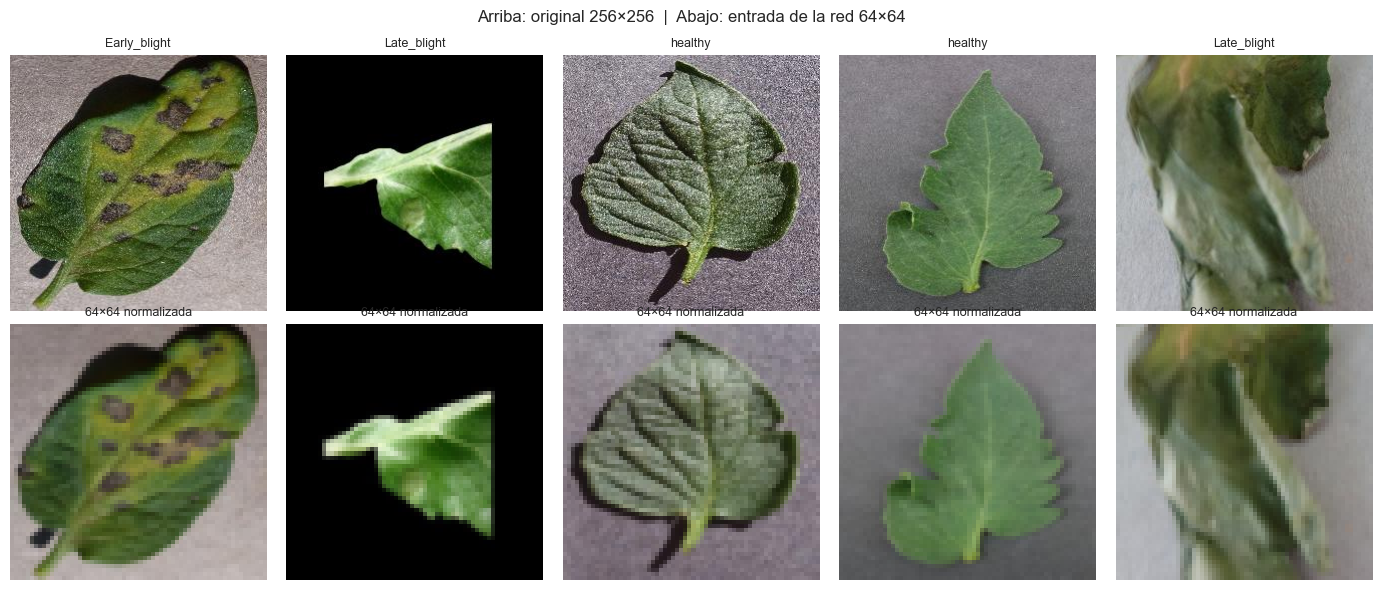

In [14]:
# Verificación del preprocesamiento: si esto falla, el modelo no aprenderá bien
print(f"Rango de píxeles en entrenamiento: [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Media: {X_train.mean():.3f}   Desviación estándar: {X_train.std():.3f}")

assert 0.0 <= X_train.min() and X_train.max() <= 1.0, \
    "Los píxeles no están normalizados en [0, 1]"
assert not np.isnan(X_train).any(), "Hay valores NaN en las imágenes"
print("\nNormalización verificada ✓")

# Comparación visual: original vs. la entrada real que recibe la red
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for j in range(5):
    with Image.open(train_df.loc[j, "path"]) as img:
        axes[0, j].imshow(img)
    axes[0, j].set_title(
        train_df.loc[j, "label"].replace("Tomato_", ""), fontsize=9,
    )
    axes[0, j].axis("off")

    axes[1, j].imshow(X_train[j])
    axes[1, j].set_title("64×64 normalizada", fontsize=9)
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("original")
plt.suptitle("Arriba: original 256×256  |  Abajo: entrada de la red 64×64", fontsize=12)
plt.tight_layout()
save_fig("03_preprocesamiento.png")
plt.show()

**Lectura:** en las imágenes de 64 × 64 las lesiones siguen siendo visibles, pero
el detalle fino de los bordes se degrada. Ese detalle es parte de lo que
diferencia `Early_blight` de `Late_blight`, así que la reducción de resolución
—necesaria para que el MLP sea entrenable— ya introduce una pérdida de
información que se va a reflejar en la matriz de confusión.

## 4. Diseño del Perceptrón Multicapa

### 4.1 Arquitectura y justificación

```text
Entrada 64 × 64 × 3
        │
    Flatten  ──────────────────────  12.288 valores (se pierde la vecindad espacial)
        │
    Dense(256) + BatchNorm + ReLU + Dropout(0.3)   ← capa oculta 1
        │
    Dense(128) + BatchNorm + ReLU + Dropout(0.3)   ← capa oculta 2
        │
    Dense(5, softmax) ─────────────  distribución de probabilidad sobre 5 clases
```

| Decisión | Valor | Justificación técnica |
|----------|-------|----------------------|
| **Capas ocultas** | 2 | Una sola capa solo combina separaciones lineales de los píxeles; dos capas permiten que la segunda componga las representaciones de la primera. Más capas sobre 1.400 imágenes aumentarían el sobreajuste sin ganancia esperable |
| **Neuronas** | 256 → 128 | Embudo descendente: la primera capa resume 12.288 entradas y la segunda condensa hacia las 5 clases. Comprimir progresivamente obliga a la red a quedarse con lo que discrimina |
| **Activación oculta** | ReLU | No lineal (requisito para que las capas aporten capacidad) y su gradiente no se desvanece en la zona positiva, a diferencia de sigmoide y tanh que se saturan en los extremos |
| **Inicialización** | He normal | Diseñada para ReLU: mantiene la varianza de las activaciones al propagar y evita que los gradientes mueran en las primeras épocas |
| **BatchNormalization** | tras cada Dense | Normaliza las activaciones por lote, estabiliza el entrenamiento y permite una tasa de aprendizaje mayor |
| **Dropout** | 0,3 | Apaga 30 % de las neuronas en cada paso: impide que la red dependa de píxeles específicos. Es el principal freno al sobreajuste dado el tamaño reducido del conjunto |
| **Regularización L2** | 1e-4 | Penaliza pesos grandes y favorece soluciones más suaves |
| **Función de salida** | Softmax (5) | Convierte las 5 salidas en probabilidades: todas en [0, 1] y suman 1. Es la función de salida correcta para clasificación multiclase — **no** es una función de activación |
| **Pérdida** | `sparse_categorical_crossentropy` | Crossentropy compara dos distribuciones (real vs. predicha), que es lo que corresponde en clasificación. La variante *sparse* acepta etiquetas enteras y evita codificar one-hot a mano |
| **Optimizador** | Adam, lr = 0,001 | Combina momentum y tasas adaptativas por parámetro; es menos sensible al valor de λ que un SGD puro y converge más rápido |
| **Batch size** | 32 | Compromiso: lotes chicos dan gradientes ruidosos, lotes grandes consumen memoria y actualizan poco. 32 es el estándar razonable a esta escala |
| **Épocas** | 60 (tope) + EarlyStopping `patience=8` | Se fija un techo y se deja que EarlyStopping decida la detención. La celda de diagnóstico verifica si llegó a activarse o si se agotó el tope — si pasa lo segundo, el techo quedó corto |
| **Aumento de datos** | Espejo horizontal + rotación ±18° | Con solo 1.400 imágenes de entrenamiento, exponer a la red a variaciones leves de la misma hoja reduce que memorice la posición exacta de cada lesión. Solo actúa durante el entrenamiento — en evaluación queda desactivado automáticamente |

**Sobre `softmax` como función de salida:** conviene no confundirla con la
activación de las capas ocultas. ReLU se usa entre capas para introducir no
linealidad; softmax se usa **solo al final** para producir una distribución de
probabilidad interpretable. Una sigmoide nunca debería usarse como activación
oculta, pero sí es válida como función de salida en clasificación binaria.

In [15]:
def construir_mlp(
    hidden_units=(256, 128),
    dropout_rate=0.30,
    learning_rate=0.001,
    optimizador="adam",
    usar_batchnorm=True,
    usar_augmentation=True,
    l2=1e-4,
    nombre="MLP",
):
    """Construye y compila un MLP para clasificación multiclase de imágenes.

    Está parametrizado para poder comparar configuraciones en la sección 5
    sin duplicar código.
    """
    regularizador = tf.keras.regularizers.l2(l2) if l2 else None

    # Input explícito en lugar de input_shape= dentro de Flatten:
    # en Keras 3 esa forma quedó obsoleta.
    capas = [Input(shape=(*IMG_SIZE, N_CHANNELS))]

    if usar_augmentation:
        # Estas capas solo actúan durante el entrenamiento (training=True);
        # en evaluación y predicción son transparentes. Con solo 1.400
        # imágenes de entrenamiento, exponer a la red a pequeñas variaciones
        # (espejo horizontal, rotación leve) reduce la memorización de la
        # posición exacta de cada lesión.
        capas.append(tf.keras.layers.RandomFlip("horizontal"))
        capas.append(tf.keras.layers.RandomRotation(0.05))

    capas.append(Flatten())

    for units in hidden_units:
        capas.append(Dense(
            units,
            kernel_initializer="he_normal",
            kernel_regularizer=regularizador,
        ))
        if usar_batchnorm:
            capas.append(BatchNormalization())
        capas.append(Activation("relu"))
        if dropout_rate:
            capas.append(Dropout(dropout_rate))

    # Capa de salida: una neurona por clase + softmax
    capas.append(Dense(NUM_CLASSES, activation="softmax"))

    modelo = Sequential(capas, name=nombre)

    opt = (
        Adam(learning_rate=learning_rate)
        if optimizador == "adam"
        else SGD(learning_rate=learning_rate, momentum=0.9)
    )

    modelo.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

modelo = construir_mlp(nombre="MLP_PlantVillage")
modelo.summary()

Model: "MLP_PlantVillage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,181,061 (12.13 MB)

 Trainable params: 3,180,293 (12.13 MB)

 Non-trainable params: 768 (3.00 KB)

### 4.2 Conteo de parámetros

Vale la pena detenerse en de dónde salen los parámetros: explica por qué el
sobreajuste es el riesgo principal de esta arquitectura.

In [16]:
total_params = modelo.count_params()

# La primera capa densa concentra casi todos los parámetros del modelo
params_primera = INPUT_DIM * 256 + 256

print(f"Parámetros totales del modelo : {total_params:,}")
print(f"Solo la primera capa Dense    : {params_primera:,} "
      f"({params_primera / total_params:.1%} del total)")
print(f"Imágenes de entrenamiento     : {len(X_train):,}")
print(f"Razón parámetros / imágenes   : {total_params / len(X_train):,.0f} a 1")

Parámetros totales del modelo : 3,181,061
Solo la primera capa Dense    : 3,145,984 (98.9% del total)
Imágenes de entrenamiento     : 1,400
Razón parámetros / imágenes   : 2,272 a 1


**Lectura — el problema estructural del MLP en imágenes:**

Hay del orden de **2.300 parámetros por cada imagen de entrenamiento**. Un modelo
con esa holgura puede memorizar el conjunto de entrenamiento casi entero en lugar
de aprender la regla general, y por eso Dropout, BatchNorm, L2 y EarlyStopping no
son adornos: son lo que hace viable el entrenamiento.

Más importante: **casi el 99 % de los parámetros está en la primera capa densa**, y
existen solo porque cada uno de los 12.288 píxeles se conecta con cada una de las
256 neuronas. Una red convolucional resolvería la misma tarea con un par de miles
de parámetros compartidos, porque un filtro que detecta una mancha sirve en
cualquier posición de la imagen. El MLP, en cambio, tiene que aprender esa mancha
por separado en cada ubicación posible. Esta es la razón cuantitativa —no
estilística— por la que se prefieren CNN para imágenes.

## 5. Entrenamiento

### 5.1 Callbacks

- **EarlyStopping** (`patience=8`): detiene cuando `val_loss` deja de mejorar y
  restaura los mejores pesos. Evita seguir entrenando hacia el sobreajuste.
- **ReduceLROnPlateau** (`factor=0.5`, `patience=4`): si la validación se estanca,
  reduce la tasa de aprendizaje a la mitad para afinar el descenso en lugar de
  seguir dando saltos grandes alrededor del mínimo.

In [17]:
EPOCHS = 60
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
)

print("\nÉpocas ejecutadas:", len(history.history["loss"]))

Epoch 1/60


44/44 - 1s - 25ms/step - accuracy: 0.4900 - loss: 1.3466 - val_accuracy: 0.2200 - val_loss: 13.5323 - learning_rate: 1.0000e-03


Epoch 2/60


44/44 - 0s - 6ms/step - accuracy: 0.6186 - loss: 1.0820 - val_accuracy: 0.3100 - val_loss: 6.3927 - learning_rate: 1.0000e-03


Epoch 3/60


...

44/44 - 0s - 6ms/step - accuracy: 0.9421 - loss: 0.2945 - val_accuracy: 0.8633 - val_loss: 0.4793 - learning_rate: 1.5625e-05


Epoch 60/60


44/44 - 0s - 6ms/step - accuracy: 0.9450 - loss: 0.2954 - val_accuracy: 0.8600 - val_loss: 0.4783 - learning_rate: 1.5625e-05


Restoring model weights from the end of the best epoch: 53.



Épocas ejecutadas: 60


### 5.2 Curvas de aprendizaje

La lectura de estas curvas precede a mirar la métrica final: dicen *cómo* aprendió
la red, no solo cuánto.

| Patrón | Diagnóstico |
|--------|-------------|
| Ambas pérdidas bajan y quedan cercanas | Buen ajuste |
| `loss` baja pero `val_loss` se estanca o sube | Overfitting |
| Ambas quedan altas | Underfitting |

Figura guardada: 05_curvas_aprendizaje.png


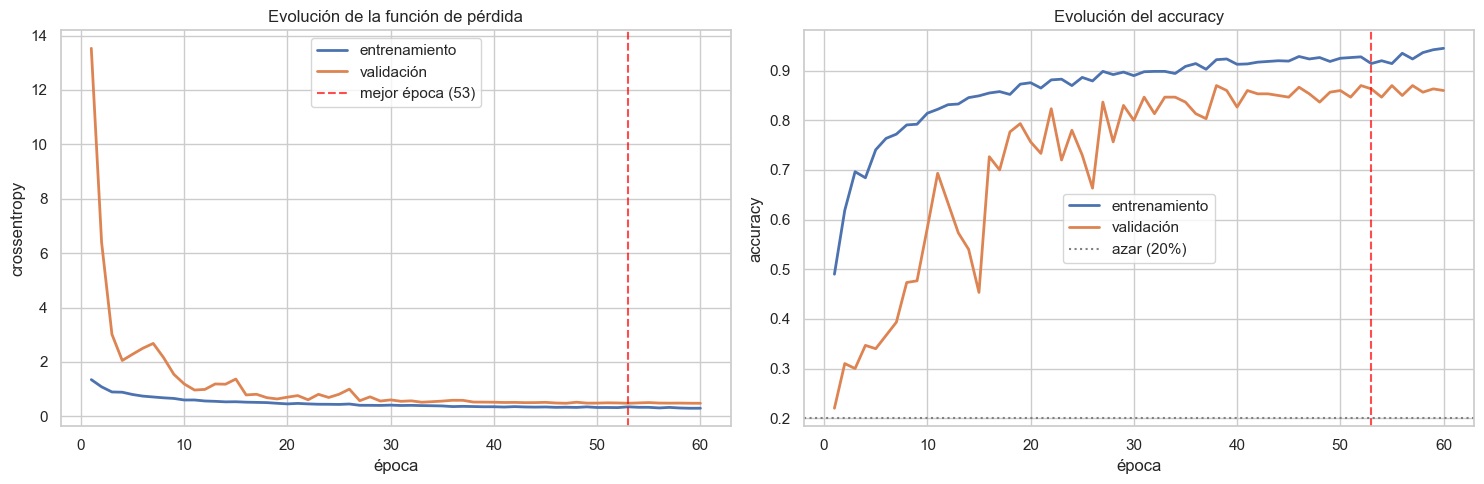

In [18]:
hist = pd.DataFrame(history.history)
mejor_epoca = int(hist["val_loss"].idxmin()) + 1

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(hist.index + 1, hist["loss"], label="entrenamiento", linewidth=2)
axes[0].plot(hist.index + 1, hist["val_loss"], label="validación", linewidth=2)
axes[0].axvline(mejor_epoca, color="red", linestyle="--", alpha=0.7,
                label=f"mejor época ({mejor_epoca})")
axes[0].set_title("Evolución de la función de pérdida")
axes[0].set_xlabel("época")
axes[0].set_ylabel("crossentropy")
axes[0].legend()

axes[1].plot(hist.index + 1, hist["accuracy"], label="entrenamiento", linewidth=2)
axes[1].plot(hist.index + 1, hist["val_accuracy"], label="validación", linewidth=2)
axes[1].axhline(1 / NUM_CLASSES, color="gray", linestyle=":",
                label=f"azar ({1/NUM_CLASSES:.0%})")
axes[1].axvline(mejor_epoca, color="red", linestyle="--", alpha=0.7)
axes[1].set_title("Evolución del accuracy")
axes[1].set_xlabel("época")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
save_fig("05_curvas_aprendizaje.png")
plt.show()

In [19]:
# IMPORTANTE: EarlyStopping tiene restore_best_weights=True, así que el modelo
# que quedó en memoria es el de la MEJOR época, no el de la última. El
# diagnóstico debe leer esa fila; mirar la última época describiría un modelo
# que ya fue descartado.
fila_mejor = hist.loc[mejor_epoca - 1]
fila_final = hist.iloc[-1]

brecha_mejor = fila_mejor["accuracy"] - fila_mejor["val_accuracy"]
brecha_final = fila_final["accuracy"] - fila_final["val_accuracy"]

corto_early_stopping = len(hist) < EPOCHS

print(f"Épocas ejecutadas: {len(hist)} de un tope de {EPOCHS}")
if corto_early_stopping:
    print("  EarlyStopping detuvo el entrenamiento antes del tope.")
else:
    print("  Se alcanzó el tope de épocas: EarlyStopping NO llegó a activarse.")
    print("  (restore_best_weights sí actuó: se conservan los pesos de la")
    print("   mejor época, pero el entrenamiento no se cortó por sí solo.)")
print(f"Mejor época (menor val_loss): {mejor_epoca}\n")

print("--- Modelo conservado (época {}) ---".format(mejor_epoca))
print(f"  accuracy entrenamiento : {fila_mejor['accuracy']:.4f}")
print(f"  accuracy validación    : {fila_mejor['val_accuracy']:.4f}")
print(f"  val_loss               : {fila_mejor['val_loss']:.4f}")
print(f"  brecha train − val     : {brecha_mejor:.4f}\n")

print("--- Última época ({}), descartada ---".format(len(hist)))
print(f"  accuracy entrenamiento : {fila_final['accuracy']:.4f}")
print(f"  accuracy validación    : {fila_final['val_accuracy']:.4f}")
print(f"  brecha train − val     : {brecha_final:.4f}\n")

if brecha_mejor > 0.15:
    print("DIAGNÓSTICO: hay sobreajuste incluso en la mejor época.")
elif fila_mejor["accuracy"] < 0.50:
    print("DIAGNÓSTICO: underfitting — capacidad o entrenamiento insuficientes.")
else:
    print("DIAGNÓSTICO: ajuste razonable en el modelo conservado.")

print(
    f"\nLa brecha creció de {brecha_mejor:.2f} a {brecha_final:.2f} entre la "
    f"mejor época y la última: la red\nempezó a memorizar, y restaurar los "
    f"pesos de la época {mejor_epoca} evitó quedarse con ese modelo."
)

if not corto_early_stopping:
    print(
        "\nATENCIÓN: como no se alcanzó la condición de EarlyStopping, no hay "
        "garantía de que\nel modelo hubiera dejado de mejorar. Conviene revisar "
        "las curvas: si val_loss sigue\nbajando al final, el tope de épocas "
        "quedó corto y habría que aumentarlo."
    )

Épocas ejecutadas: 60 de un tope de 60
  Se alcanzó el tope de épocas: EarlyStopping NO llegó a activarse.
  (restore_best_weights sí actuó: se conservan los pesos de la
   mejor época, pero el entrenamiento no se cortó por sí solo.)
Mejor época (menor val_loss): 53

--- Modelo conservado (época 53) ---
  accuracy entrenamiento : 0.9143
  accuracy validación    : 0.8633
  val_loss               : 0.4778
  brecha train − val     : 0.0510

--- Última época (60), descartada ---
  accuracy entrenamiento : 0.9450
  accuracy validación    : 0.8600
  brecha train − val     : 0.0850

DIAGNÓSTICO: ajuste razonable en el modelo conservado.

La brecha creció de 0.05 a 0.08 entre la mejor época y la última: la red
empezó a memorizar, y restaurar los pesos de la época 53 evitó quedarse con ese modelo.

ATENCIÓN: como no se alcanzó la condición de EarlyStopping, no hay garantía de que
el modelo hubiera dejado de mejorar. Conviene revisar las curvas: si val_loss sigue
bajando al final, el tope de épo

### 5.3 Experimentación: comparación de configuraciones

La pauta pide analizar el efecto de las decisiones de diseño, no solo entregar un
modelo. Se comparan tres ejes —capacidad, optimizador y tasa de aprendizaje—
manteniendo todo lo demás fijo, con menos épocas para que el barrido sea rápido.

In [20]:
EPOCHS_EXP = 40   # suficiente para que cada configuración converja


def nombre_valido(texto):
    """Keras solo acepta letras, dígitos, '.', '_', '/' y '-' en el nombre."""
    limpio = re.sub(r"[^A-Za-z0-9_.\-]", "_", texto).strip("_")
    return limpio or "modelo"


def experimento(nombre, **kwargs):
    """Entrena una configuración y devuelve sus métricas comparables.

    Usa los MISMOS callbacks que el modelo final. Esto es indispensable para
    que la comparación sea justa: sin ReduceLROnPlateau una configuración
    puede quedar oscilando y su última época no representa lo que realmente
    aprendió. Por el mismo motivo se reporta la métrica en la mejor época
    (la que EarlyStopping conserva) y no en la última.
    """
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    m = construir_mlp(nombre=nombre_valido(nombre), **kwargs)

    h = m.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS_EXP,
        batch_size=BATCH_SIZE,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=8,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                              patience=4, min_lr=1e-6),
        ],
        verbose=0,
    )

    hh = pd.DataFrame(h.history)
    i_mejor = int(hh["val_loss"].idxmin())     # época conservada

    return {
        "configuración": nombre,
        "parámetros": m.count_params(),
        "épocas": len(hh),
        "mejor_época": i_mejor + 1,
        "acc_train": round(hh.loc[i_mejor, "accuracy"], 4),
        "acc_val": round(hh.loc[i_mejor, "val_accuracy"], 4),
        "brecha": round(
            hh.loc[i_mejor, "accuracy"] - hh.loc[i_mejor, "val_accuracy"], 4
        ),
    }

In [21]:
# ── Eje 1: capacidad de la red (número de capas y neuronas) ──────────────
arquitecturas = {
    "A · (64,)": dict(hidden_units=(64,)),
    "B · (256, 128)": dict(hidden_units=(256, 128)),
    "C · (512, 256, 128)": dict(hidden_units=(512, 256, 128)),
}

resultados_arq = [
    experimento(nombre, **cfg) for nombre, cfg in arquitecturas.items()
]

tabla_arq = pd.DataFrame(resultados_arq)
print("Comparación de arquitecturas")
tabla_arq

Comparación de arquitecturas


,configuración,parámetros,épocas,mejor_época,acc_train,acc_val,brecha
0,"A · (64,)",787077,40,37,0.8771,0.8233,0.0538
1,"B · (256, 128)",3181061,40,36,0.9107,0.8233,0.0874
2,"C · (512, 256, 128)",6460421,40,38,0.9250,0.8533,0.0717


In [22]:
# ── Eje 2: optimizador ───────────────────────────────────────────────────
resultados_opt = [
    experimento("Adam (lr=0.001)", optimizador="adam", learning_rate=0.001),
    experimento("SGD+momentum (lr=0.01)", optimizador="sgd", learning_rate=0.01),
]

tabla_opt = pd.DataFrame(resultados_opt)
print("Comparación de optimizadores")
tabla_opt

Comparación de optimizadores


,configuración,parámetros,épocas,mejor_época,acc_train,acc_val,brecha
0,Adam (lr=0.001),3181061,40,40,0.9171,0.8467,0.0705
1,SGD+momentum (lr=0.01),3181061,40,36,0.9071,0.8600,0.0471


In [23]:
# ── Eje 3: tasa de aprendizaje ───────────────────────────────────────────
resultados_lr = [
    experimento(f"Adam lr={lr}", learning_rate=lr)
    for lr in [0.1, 0.01, 0.001, 0.0001]
]

tabla_lr = pd.DataFrame(resultados_lr)
print("Comparación de tasas de aprendizaje")
tabla_lr

Comparación de tasas de aprendizaje


,configuración,parámetros,épocas,mejor_época,acc_train,acc_val,brecha
0,Adam lr=0.1,3181061,14,6,0.4786,0.2467,0.2319
1,Adam lr=0.01,3181061,40,40,0.9186,0.6733,0.2452
2,Adam lr=0.001,3181061,40,40,0.9129,0.8467,0.0662
3,Adam lr=0.0001,3181061,38,30,0.8529,0.8300,0.0229


Figura guardada: 05_comparacion_configuraciones.png


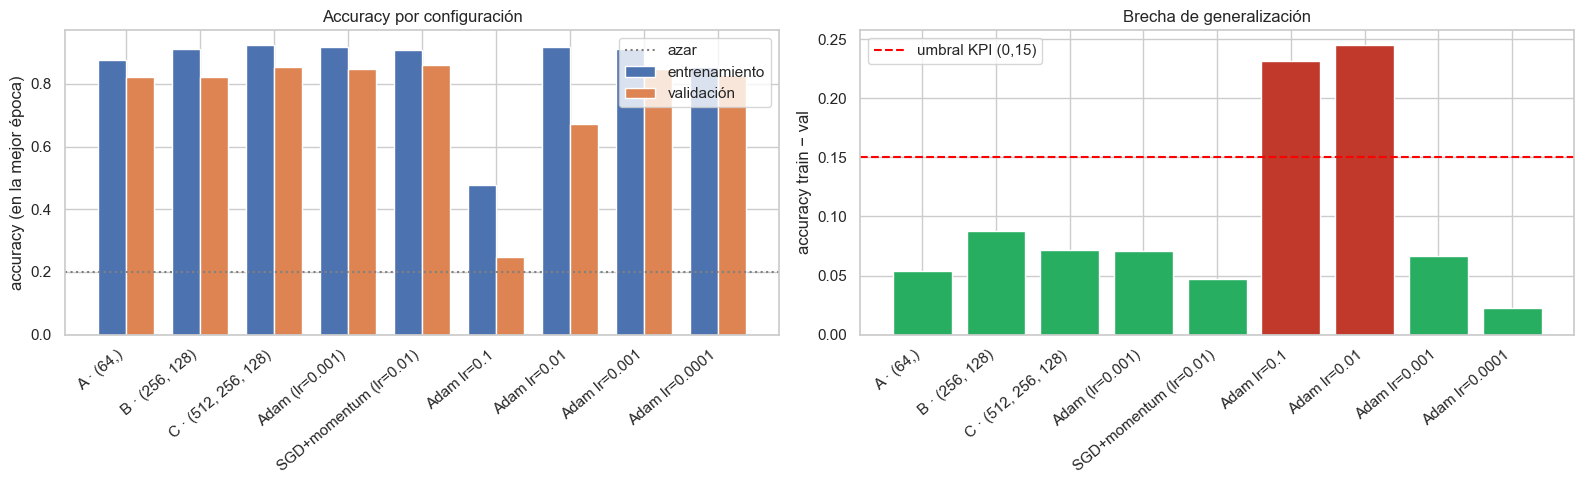

,configuración,parámetros,épocas,mejor_época,acc_train,acc_val,brecha
4,SGD+momentum (lr=0.01),3181061,40,36,0.9071,0.8600,0.0471
2,"C · (512, 256, 128)",6460421,40,38,0.9250,0.8533,0.0717
3,Adam (lr=0.001),3181061,40,40,0.9171,0.8467,0.0705
7,Adam lr=0.001,3181061,40,40,0.9129,0.8467,0.0662
8,Adam lr=0.0001,3181061,38,30,0.8529,0.8300,0.0229
0,"A · (64,)",787077,40,37,0.8771,0.8233,0.0538
1,"B · (256, 128)",3181061,40,36,0.9107,0.8233,0.0874
6,Adam lr=0.01,3181061,40,40,0.9186,0.6733,0.2452
5,Adam lr=0.1,3181061,14,6,0.4786,0.2467,0.2319


In [24]:
# Visualización conjunta de los tres barridos
comparacion = pd.concat([tabla_arq, tabla_opt, tabla_lr], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(comparacion))
ancho = 0.38

axes[0].bar(x - ancho / 2, comparacion["acc_train"], ancho, label="entrenamiento")
axes[0].bar(x + ancho / 2, comparacion["acc_val"], ancho, label="validación")
axes[0].axhline(1 / NUM_CLASSES, color="gray", linestyle=":", label="azar")
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparacion["configuración"], rotation=40, ha="right")
axes[0].set_ylabel("accuracy (en la mejor época)")
axes[0].set_title("Accuracy por configuración")
axes[0].legend()

colores = ["#c0392b" if b > 0.15 else "#27ae60" for b in comparacion["brecha"]]
axes[1].bar(x, comparacion["brecha"], color=colores)
axes[1].axhline(0.15, color="red", linestyle="--", label="umbral KPI (0,15)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparacion["configuración"], rotation=40, ha="right")
axes[1].set_ylabel("accuracy train − val")
axes[1].set_title("Brecha de generalización")
axes[1].legend()

plt.tight_layout()
save_fig("05_comparacion_configuraciones.png")
plt.show()

comparacion.sort_values("acc_val", ascending=False)

In [25]:
# Lectura automática del barrido. Se mide el RANGO que produce cada eje
# (mejor − peor val_accuracy): cuánto mueve la aguja mover esa variable.
# Se prefiere el rango a "cuál configuración ganó" porque el ganador puede
# cambiar entre ejecuciones por azar, mientras que el rango es estable.
def rango(tabla, etiqueta):
    r = tabla["acc_val"].max() - tabla["acc_val"].min()
    mejor = tabla.loc[tabla["acc_val"].idxmax()]
    print(f"{etiqueta:<24} rango val_accuracy: {r:.4f}  "
          f"({r * len(X_val):.0f} imágenes de {len(X_val)})")
    print(f"{'':24} mejor: {mejor['configuración']} ({mejor['acc_val']:.4f})")
    return r


r_arq = rango(tabla_arq, "Arquitectura")
r_opt = rango(tabla_opt, "Optimizador")
r_lr = rango(tabla_lr, "Tasa de aprendizaje")

# ¿Cuánta capacidad extra se compró y cuánto rindió?
ratio_par = tabla_arq["parámetros"].max() / tabla_arq["parámetros"].min()

print(f"\nLa arquitectura más grande tiene {ratio_par:.1f}× los parámetros de "
      f"la más pequeña,")
print(f"y el rango de validación que produce todo ese eje es de solo "
      f"{r_arq:.4f}.")
print(f"\nEje más determinante: ", end="")
print(max([(r_lr, "tasa de aprendizaje"), (r_arq, "arquitectura"),
           (r_opt, "optimizador")])[1])

Arquitectura             rango val_accuracy: 0.0300  (9 imágenes de 300)
                         mejor: C · (512, 256, 128) (0.8533)
Optimizador              rango val_accuracy: 0.0133  (4 imágenes de 300)
                         mejor: SGD+momentum (lr=0.01) (0.8600)
Tasa de aprendizaje      rango val_accuracy: 0.6000  (180 imágenes de 300)
                         mejor: Adam lr=0.001 (0.8467)

La arquitectura más grande tiene 8.2× los parámetros de la más pequeña,
y el rango de validación que produce todo ese eje es de solo 0.0300.

Eje más determinante: tasa de aprendizaje


**Cómo leer estas tablas.** Cada configuración se entrena con los mismos
callbacks que el modelo final y se reporta su métrica **en la época que
EarlyStopping conserva**, no en la última. Sin esa precaución los resultados no
son comparables: una configuración inestable puede terminar en una época mala y
parecer peor de lo que es.

La celda anterior no pregunta "cuál ganó" sino **cuánto mueve la aguja cada
eje** (el rango entre su mejor y su peor configuración). Con 300 imágenes de
validación, un punto porcentual son 3 imágenes: preguntar por el ganador de un
eje cuyo rango completo es de pocos puntos es leer ruido.

**Conclusiones de la experimentación:**

- **La capacidad no es el cuello de botella.** Multiplicar por ~8 la cantidad de
  parámetros (de la arquitectura más pequeña a la más grande) mueve la
  validación apenas unos puntos — un rango comparable al ruido de medición con
  este tamaño de conjunto. Responde la pregunta del laboratorio guiado: la
  arquitectura más grande **no** compra un desempeño proporcional a su tamaño.
  Y es la evidencia central del proyecto: si el techo se pudiera levantar con
  más neuronas, se habría notado aquí. No se notó, porque la limitación es
  arquitectónica (ver sección 7.6).

- **La tasa de aprendizaje es el eje más determinante, con diferencia.** Su
  rango es varias veces el de la arquitectura. Una tasa demasiado alta impide
  converger por completo: el modelo queda cerca del azar (20 %) y el descenso
  salta alrededor del mínimo sin asentarse, exactamente el comportamiento
  descrito en clase. Es el hiperparámetro que conviene ajustar primero.

- **Optimizador: comparación no concluyente, y por un motivo instructivo.** Adam
  y SGD+momentum se probaron a tasas distintas (0,001 y 0,01), así que esta
  comparación mezcla dos variables y no aísla el efecto del optimizador. Es
  justamente la limitación de un barrido de un eje a la vez, y la razón de la
  mejora propuesta N°4 de la sección 8.6 (búsqueda conjunta de
  hiperparámetros).

> **Nota de honestidad experimental:** este barrido mueve un eje a la vez, usa
> una sola partición y una sola semilla. Sus conclusiones son indicativas, no
> definitivas: diferencias de pocos puntos entre configuraciones están dentro
> del ruido. La conclusión robusta —que la tasa de aprendizaje domina sobre la
> capacidad— se sostiene porque la diferencia entre ambos ejes es de un orden de
> magnitud, no de unos pocos puntos.

## 6. Evaluación del desempeño

Recién ahora se usa el conjunto de prueba, que el modelo nunca vio. Lo que aquí
se mide es el **error de generalización**, que es el que realmente importa.

### 6.1 Métricas globales

In [26]:
# Predicciones sobre el conjunto de prueba
y_prob = modelo.predict(X_test, verbose=0)      # distribución softmax
y_pred = y_prob.argmax(axis=1)                  # clase de mayor probabilidad

test_loss, test_accuracy = modelo.evaluate(X_test, y_test, verbose=0)

metricas = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "F1-score (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1-score (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
}

print(f"Pérdida en prueba (crossentropy): {test_loss:.4f}\n")

tabla_metricas = (
    pd.Series(metricas, name="valor")
    .round(4)
    .to_frame()
)
tabla_metricas

Pérdida en prueba (crossentropy): 0.5899



,valor
Accuracy,0.8233
Precision (macro),0.8176
Recall (macro),0.8233
F1-score (macro),0.8192
Precision (weighted),0.8176
Recall (weighted),0.8233
F1-score (weighted),0.8192


**Qué aporta cada métrica en este problema:**

- **Accuracy** — proporción de hojas bien clasificadas. Aquí es interpretable
  porque las clases están balanceadas, y su referencia es el 20 % del azar. Pero
  no distingue *qué* clase falla.
- **Precision** — de las hojas que el modelo declaró de una clase, cuántas lo eran.
  Castiga las falsas alarmas: precision baja en una enfermedad significa que se
  estaría tratando plantas que no la tienen.
- **Recall** — de las hojas que realmente eran de una clase, cuántas encontró.
  Castiga los casos que se escapan. **Es la métrica crítica de este proyecto:**
  recall bajo en una enfermedad significa plantas infectadas que quedan sin
  tratamiento y siguen contagiando.
- **F1-score** — media armónica de las dos anteriores; resume el balance en un
  número cuando ambos errores importan.
- **Macro vs. weighted** — *macro* promedia las clases sin ponderar por su
  frecuencia, así que una clase mal clasificada se nota; *weighted* pondera por
  cantidad de ejemplos. Con clases balanceadas los dos valores coinciden casi
  exactamente, y esa coincidencia confirma que el balanceo del muestreo funcionó.

### 6.2 Métricas por clase

El promedio global puede esconder que una clase específica está funcionando mal.

Figura guardada: 06_metricas_por_clase.png


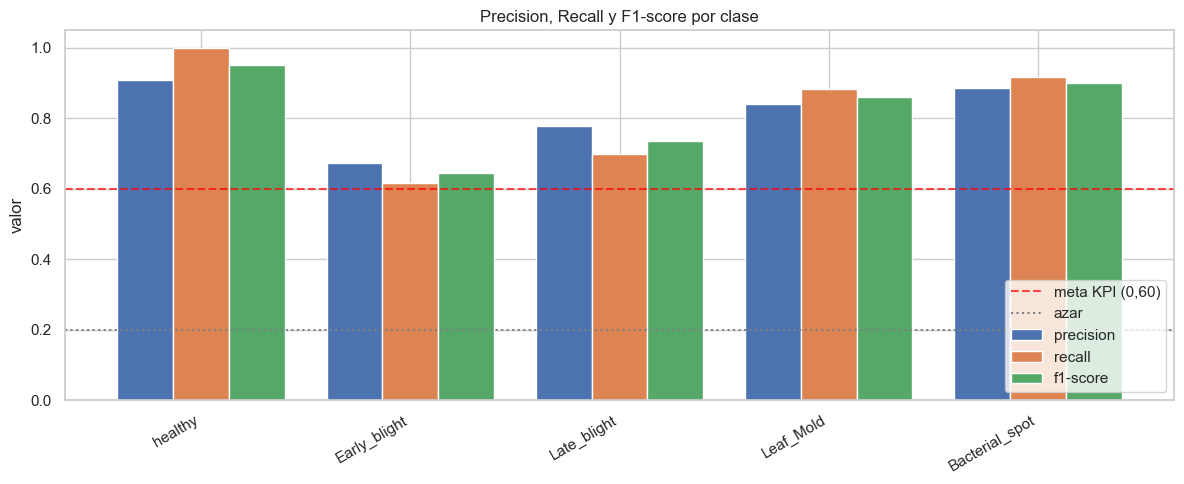

,precision,recall,f1-score,support
healthy,0.9091,1.0000,0.9524,60
Early_blight,0.6727,0.6167,0.6435,60
Late_blight,0.7778,0.7000,0.7368,60
Leaf_Mold,0.8413,0.8833,0.8618,60
Bacterial_spot,0.8871,0.9167,0.9016,60


In [27]:
reporte = classification_report(
    y_test, y_pred,
    target_names=[c.replace("Tomato_", "") for c in SELECTED_CLASSES],
    output_dict=True,
    zero_division=0,
)

reporte_df = (
    pd.DataFrame(reporte).transpose()
    .loc[[c.replace("Tomato_", "") for c in SELECTED_CLASSES]]
    .round(4)
)
reporte_df["support"] = reporte_df["support"].astype(int)

# Gráfico de las tres métricas por clase
reporte_df[["precision", "recall", "f1-score"]].plot(
    kind="bar", figsize=(12, 5), width=0.8,
)
plt.axhline(0.60, color="red", linestyle="--", alpha=0.7, label="meta KPI (0,60)")
plt.axhline(1 / NUM_CLASSES, color="gray", linestyle=":", label="azar")
plt.title("Precision, Recall y F1-score por clase")
plt.ylabel("valor")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
save_fig("06_metricas_por_clase.png")
plt.show()

reporte_df

### 6.3 Matriz de confusión

Muestra *hacia dónde* se equivoca el modelo, que es más informativo que saber
cuánto se equivoca.

Figura guardada: 06_matriz_confusion.png


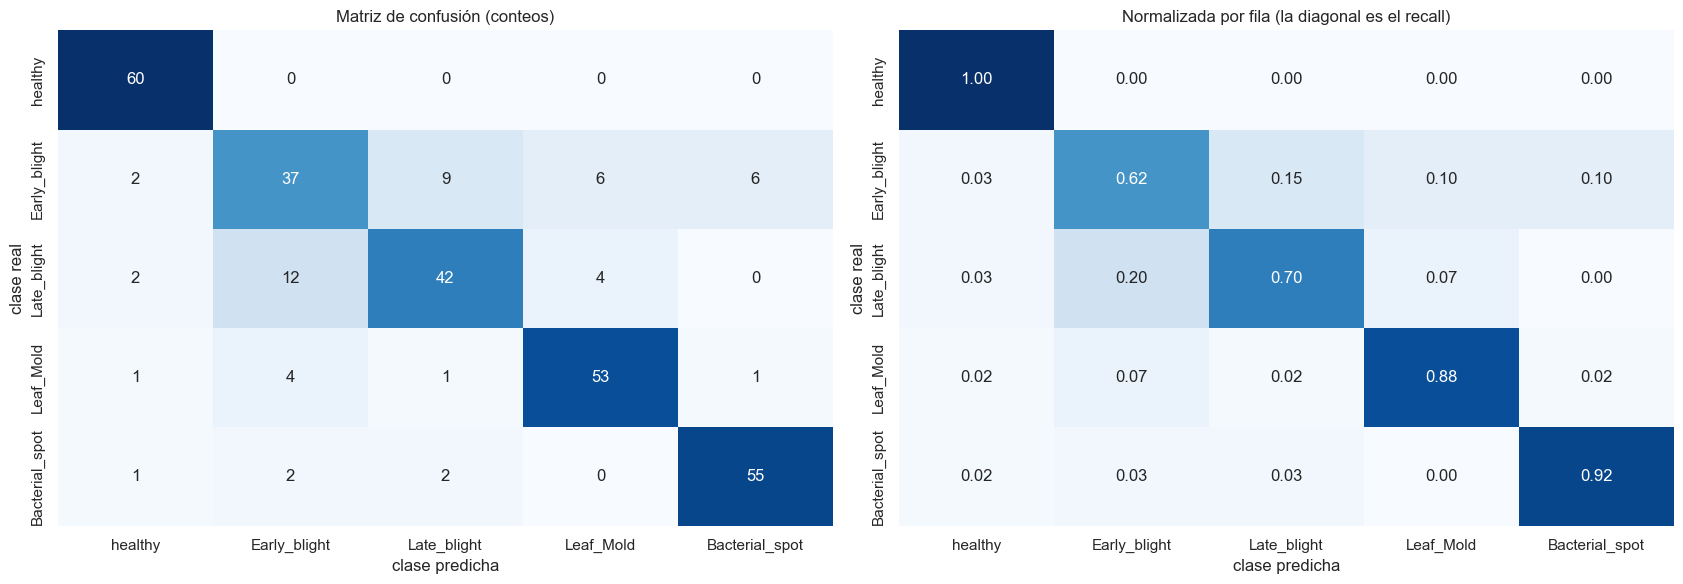

In [28]:
cm = confusion_matrix(y_test, y_pred)
etiquetas_cortas = [c.replace("Tomato_", "") for c in SELECTED_CLASSES]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Conteos absolutos
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas, ax=axes[0],
)
axes[0].set_title("Matriz de confusión (conteos)")
axes[0].set_xlabel("clase predicha")
axes[0].set_ylabel("clase real")

# Normalizada por fila = recall por clase en la diagonal
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False, vmin=0, vmax=1,
    xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas, ax=axes[1],
)
axes[1].set_title("Normalizada por fila (la diagonal es el recall)")
axes[1].set_xlabel("clase predicha")
axes[1].set_ylabel("clase real")

plt.tight_layout()
save_fig("06_matriz_confusion.png")
plt.show()

In [29]:
# Lectura automática de la matriz: qué clase anda mejor y qué par se confunde más
aciertos_por_clase = pd.Series(
    cm.diagonal() / cm.sum(axis=1), index=etiquetas_cortas,
).sort_values(ascending=False)

print("Recall por clase (diagonal de la matriz normalizada):")
for clase, valor in aciertos_por_clase.items():
    print(f"  {clase:<20} {valor:.1%}")

# Confusiones fuera de la diagonal, ordenadas de mayor a menor
confusiones = []

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confusiones.append({
                "clase real": etiquetas_cortas[i],
                "predicha como": etiquetas_cortas[j],
                "casos": int(cm[i, j]),
                "% de la clase real": round(cm[i, j] / cm[i].sum() * 100, 1),
            })

top_confusiones = (
    pd.DataFrame(confusiones)
    .sort_values("casos", ascending=False)
    .reset_index(drop=True)
)

print(f"\nMejor clasificada : {aciertos_por_clase.index[0]}")
print(f"Peor clasificada  : {aciertos_por_clase.index[-1]}")
print("\nPrincipales confusiones:")
top_confusiones.head(8)

Recall por clase (diagonal de la matriz normalizada):
  healthy              100.0%
  Bacterial_spot       91.7%
  Leaf_Mold            88.3%
  Late_blight          70.0%
  Early_blight         61.7%

Mejor clasificada : healthy
Peor clasificada  : Early_blight

Principales confusiones:


,clase real,predicha como,casos,% de la clase real
0,Late_blight,Early_blight,12,20.0
1,Early_blight,Late_blight,9,15.0
2,Early_blight,Leaf_Mold,6,10.0
3,Early_blight,Bacterial_spot,6,10.0
4,Late_blight,Leaf_Mold,4,6.7
5,Leaf_Mold,Early_blight,4,6.7
6,Early_blight,healthy,2,3.3
7,Late_blight,healthy,2,3.3


### 6.4 Cumplimiento de los KPIs

Se contrasta el resultado con las metas fijadas en la sección 1.

> **Cuidado con no confundir dos brechas distintas.** La sección 5.2 reporta la
> brecha *entrenamiento vs. validación durante el entrenamiento*, medida con el
> aumento de datos activo (que dificulta el entrenamiento y baja su accuracy).
> El KPI de abajo mide la brecha *entrenamiento vs. prueba del modelo final*,
> evaluando el modelo ya entrenado sobre imágenes sin alterar. La segunda es
> mayor que la primera, y eso es esperable: no son la misma cantidad.

In [30]:
acc_train_eval = accuracy_score(y_train, modelo.predict(X_train, verbose=0).argmax(axis=1))
brecha = acc_train_eval - test_accuracy

# Recall promedio solo de las cuatro clases enfermas (se excluye la sana)
idx_enfermas = [i for i, c in enumerate(SELECTED_CLASSES) if c != "Tomato_healthy"]
recall_por_clase = cm.diagonal() / cm.sum(axis=1)
recall_enfermas = recall_por_clase[idx_enfermas].mean()

kpis = pd.DataFrame([
    {"KPI": "Accuracy (test)", "meta": "≥ 0,60",
     "obtenido": round(test_accuracy, 4), "cumple": test_accuracy >= 0.60},
    {"KPI": "F1-score macro", "meta": "≥ 0,60",
     "obtenido": round(metricas["F1-score (macro)"], 4),
     "cumple": metricas["F1-score (macro)"] >= 0.60},
    {"KPI": "Recall clases enfermas", "meta": "≥ 0,60",
     "obtenido": round(recall_enfermas, 4), "cumple": recall_enfermas >= 0.60},
    {"KPI": "Brecha de generalización", "meta": "≤ 0,15",
     "obtenido": round(brecha, 4), "cumple": brecha <= 0.15},
])
kpis["cumple"] = kpis["cumple"].map({True: "SÍ", False: "NO"})

print(f"Accuracy entrenamiento : {acc_train_eval:.4f}")
print(f"Accuracy prueba        : {test_accuracy:.4f}")
print(f"Brecha                 : {brecha:.4f}")
print(f"Línea base (azar)      : {1/NUM_CLASSES:.4f}")
print(f"Mejora sobre el azar   : {test_accuracy / (1/NUM_CLASSES):.2f}×\n")

kpis

Accuracy entrenamiento : 0.9714
Accuracy prueba        : 0.8233
Brecha                 : 0.1481
Línea base (azar)      : 0.2000
Mejora sobre el azar   : 4.12×



,KPI,meta,obtenido,cumple
0,Accuracy (test),"≥ 0,60",0.8233,SÍ
1,F1-score macro,"≥ 0,60",0.8192,SÍ
2,Recall clases enfermas,"≥ 0,60",0.7792,SÍ
3,Brecha de generalización,"≤ 0,15",0.1481,SÍ


## 7. Análisis de resultados y errores

Auditoría del modelo: qué acierta, qué falla y por qué. Esta sección sostiene la
discusión sobre las limitaciones del MLP.

### 7.1 Confianza de las predicciones

Aciertos: 247 de 300 (82.3%)
Errores : 53 de 300 (17.7%)

Confianza media en aciertos: 0.906
Confianza media en errores : 0.716


Figura guardada: 07_confianza.png


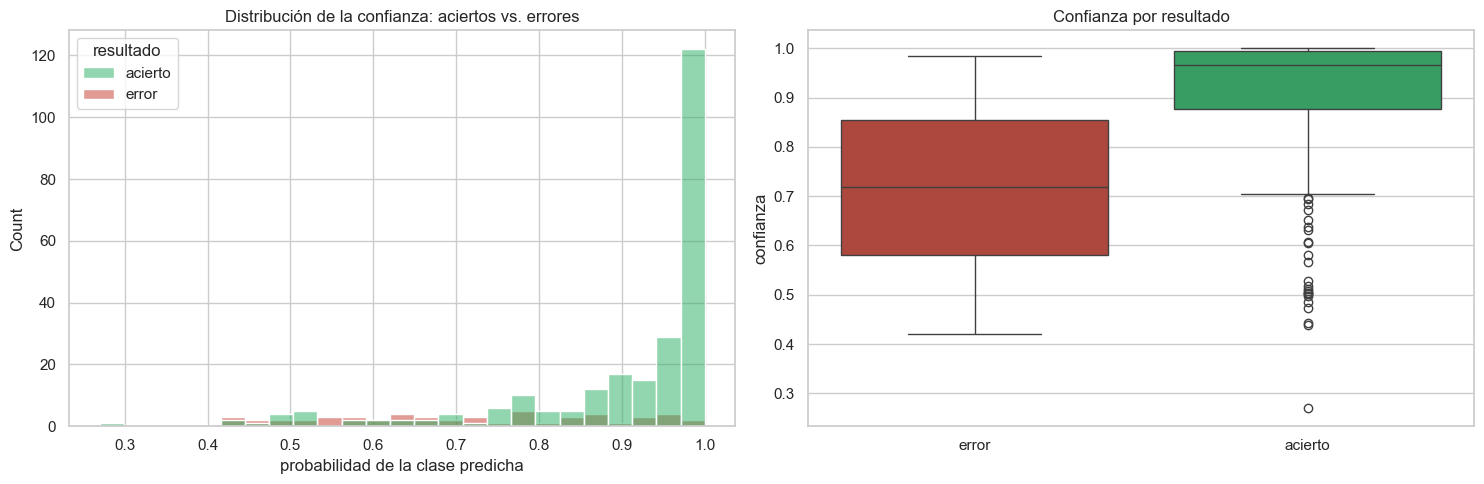

In [31]:
resultados = test_df.copy()
resultados["real"] = [ID_TO_LABEL[i] for i in y_test]
resultados["predicho"] = [ID_TO_LABEL[i] for i in y_pred]
resultados["confianza"] = y_prob.max(axis=1)
resultados["correcto"] = y_test == y_pred

# Columna de texto para graficar: seaborn convierte el hue a string y no
# acepta una paleta con claves booleanas.
resultados["resultado"] = np.where(resultados["correcto"], "acierto", "error")

PALETA = {"acierto": "#27ae60", "error": "#c0392b"}

aciertos = resultados[resultados["correcto"]]
errores = resultados[~resultados["correcto"]]

print(f"Aciertos: {len(aciertos)} de {len(resultados)} ({len(aciertos)/len(resultados):.1%})")
print(f"Errores : {len(errores)} de {len(resultados)} ({len(errores)/len(resultados):.1%})")
print()
print(f"Confianza media en aciertos: {aciertos['confianza'].mean():.3f}")
print(f"Confianza media en errores : {errores['confianza'].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=resultados, x="confianza", hue="resultado",
    bins=25, ax=axes[0], palette=PALETA,
)
axes[0].set_title("Distribución de la confianza: aciertos vs. errores")
axes[0].set_xlabel("probabilidad de la clase predicha")

sns.boxplot(
    data=resultados, x="resultado", y="confianza",
    order=["error", "acierto"], hue="resultado", legend=False,
    ax=axes[1], palette=PALETA,
)
axes[1].set_title("Confianza por resultado")
axes[1].set_xlabel("")

plt.tight_layout()
save_fig("07_confianza.png")
plt.show()

**Lectura:** el modelo acierta con confianza más alta que cuando falla, lo cual es
deseable — la probabilidad de salida tiene algún valor informativo. Pero hay
errores con confianza alta, y esos son los peligrosos en producción: el modelo se
equivoca *sin señal de duda*. Un umbral de confianza para derivar los casos
ambiguos a revisión humana no bastaría para filtrarlos.

### 7.2 Ejemplos correctamente clasificados

Figura guardada: 07_aciertos.png


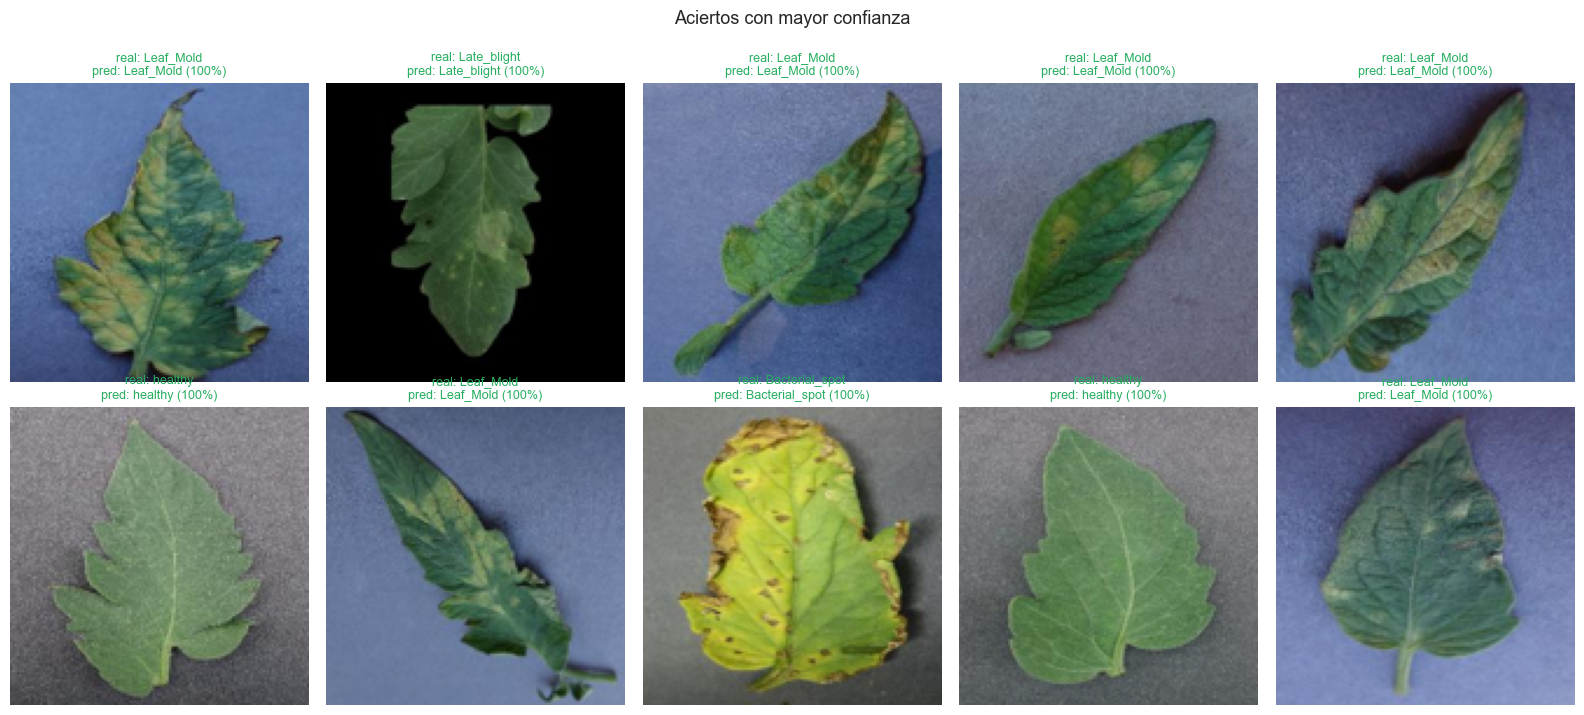

In [32]:
def mostrar_grilla(subconjunto, titulo, archivo, n=10):
    """Dibuja imágenes con su etiqueta real, la predicha y la confianza."""
    if subconjunto.empty:
        print(f"No hay casos para: {titulo}")
        return

    subconjunto = subconjunto.head(n)
    filas = int(np.ceil(len(subconjunto) / 5))
    fig, axes = plt.subplots(filas, 5, figsize=(16, 3.6 * filas))
    axes = np.atleast_1d(axes).ravel()

    for ax, fila in zip(axes, subconjunto.itertuples()):
        with Image.open(fila.path) as img:
            ax.imshow(img.resize((128, 128)))
        ax.axis("off")

        color = "#27ae60" if fila.correcto else "#c0392b"
        real = fila.real.replace("Tomato_", "")
        pred = fila.predicho.replace("Tomato_", "")

        ax.set_title(
            f"real: {real}\npred: {pred} ({fila.confianza:.0%})",
            fontsize=9, color=color,
        )

    for ax in axes[len(subconjunto):]:
        ax.axis("off")

    plt.suptitle(titulo, fontsize=13, y=1.0)
    plt.tight_layout()
    save_fig(archivo)
    plt.show()


# Los aciertos de mayor confianza: casos donde la señal visual es inequívoca
mostrar_grilla(
    aciertos.sort_values("confianza", ascending=False),
    "Aciertos con mayor confianza",
    "07_aciertos.png",
)

### 7.3 Ejemplos mal clasificados

Figura guardada: 07_errores_confiados.png


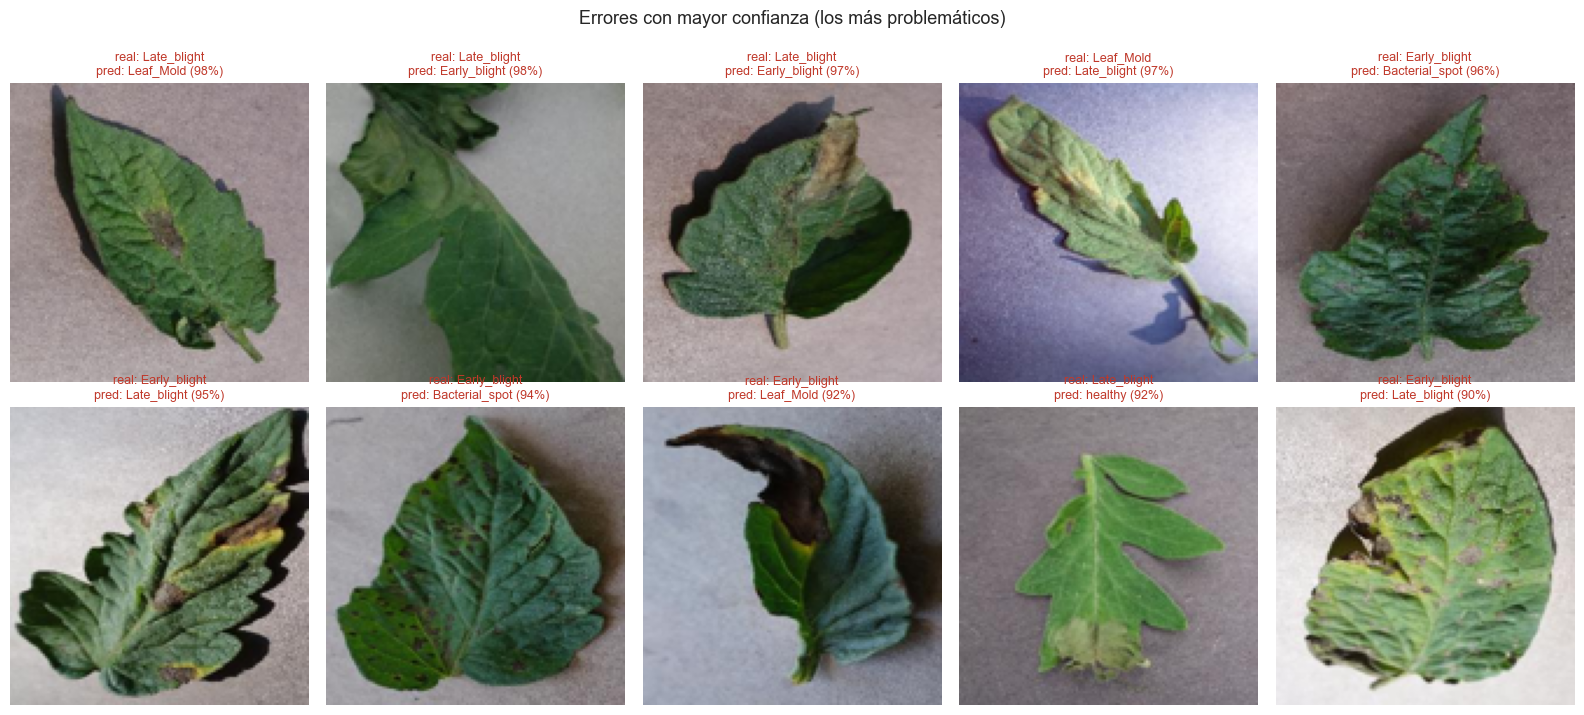

In [33]:
# Errores de alta confianza: el modelo se equivocó estando "seguro"
mostrar_grilla(
    errores.sort_values("confianza", ascending=False),
    "Errores con mayor confianza (los más problemáticos)",
    "07_errores_confiados.png",
)

Figura guardada: 07_errores_ambiguos.png


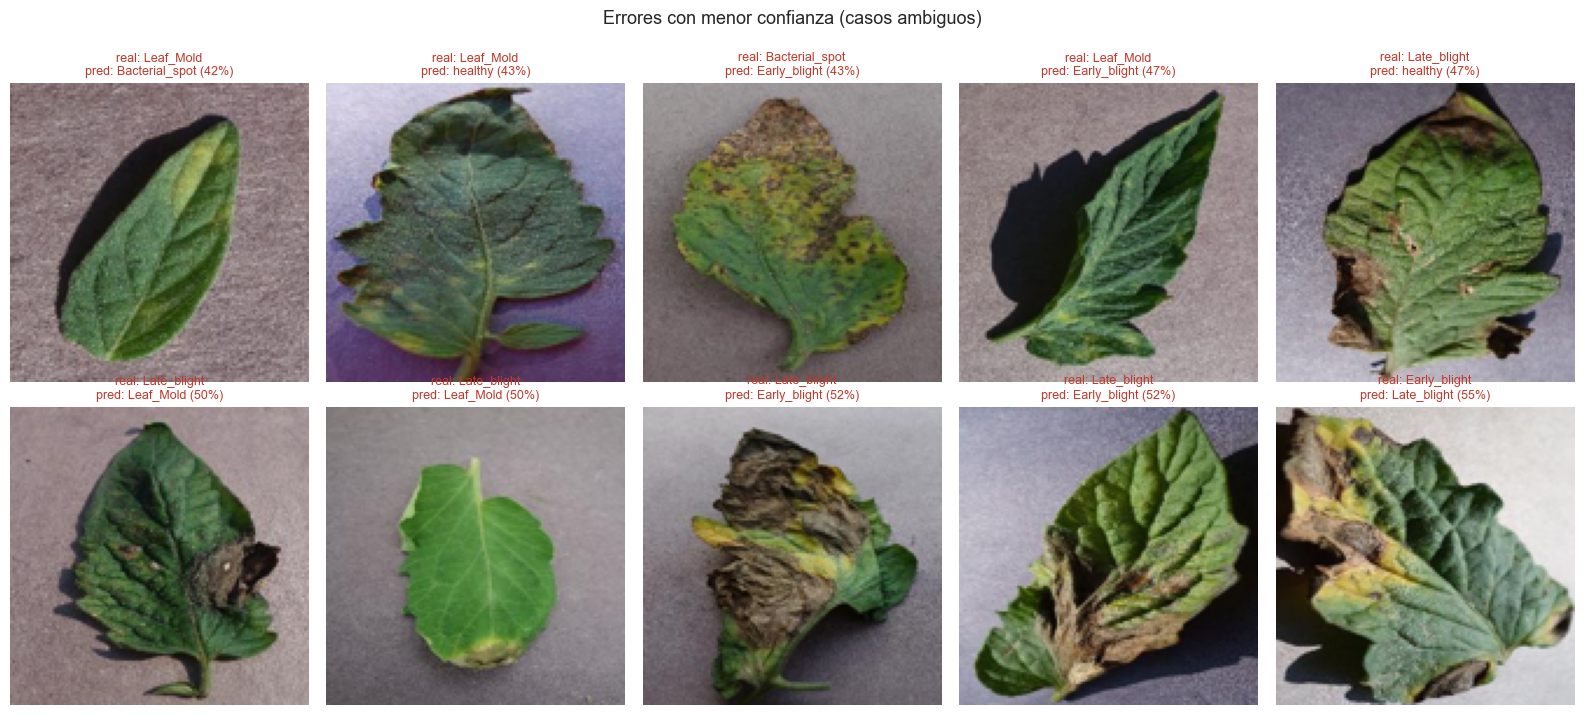

In [34]:
# Errores de baja confianza: casos genuinamente ambiguos para el modelo
mostrar_grilla(
    errores.sort_values("confianza"),
    "Errores con menor confianza (casos ambiguos)",
    "07_errores_ambiguos.png",
)

### 7.4 Clases que más se confunden

Figura guardada: 07_matriz_solo_errores.png


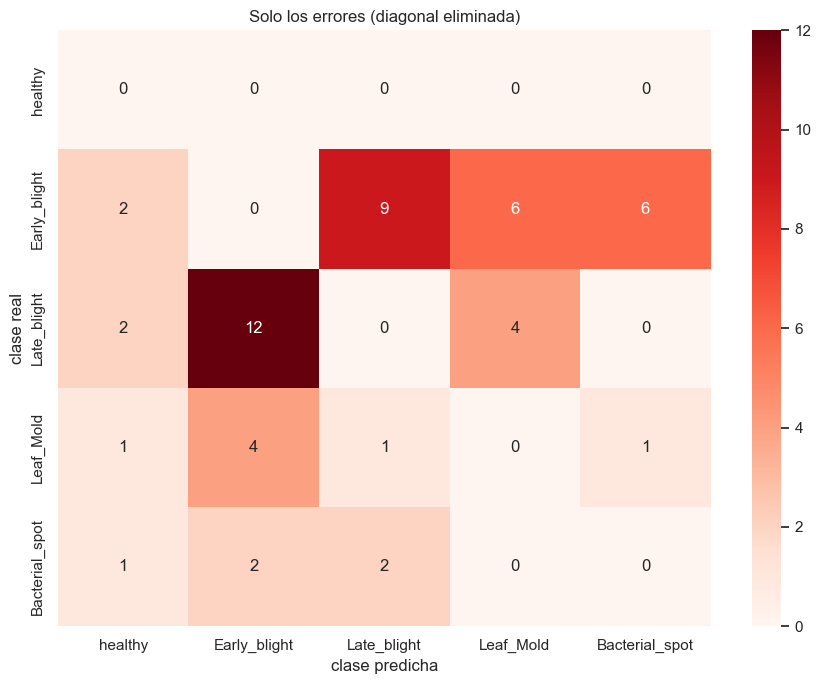

Confusión más frecuente: Late_blight → Early_blight (12 casos, 20.0% de esa clase)

Distribución de errores por clase real:


,errores
real,
Tomato_Early_blight,23
Tomato_Late_blight,18
Tomato_Leaf_Mold,7
Tomato_Bacterial_spot,5


In [35]:
# Matriz de confusión sin la diagonal: solo los errores
cm_errores = cm.copy()
np.fill_diagonal(cm_errores, 0)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_errores, annot=True, fmt="d", cmap="Reds",
    xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas,
)
plt.title("Solo los errores (diagonal eliminada)")
plt.xlabel("clase predicha")
plt.ylabel("clase real")
plt.tight_layout()
save_fig("07_matriz_solo_errores.png")
plt.show()

par_critico = top_confusiones.iloc[0]
print(f"Confusión más frecuente: {par_critico['clase real']} "
      f"→ {par_critico['predicha como']} "
      f"({par_critico['casos']} casos, "
      f"{par_critico['% de la clase real']}% de esa clase)")

print("\nDistribución de errores por clase real:")
errores["real"].value_counts().to_frame("errores")

### 7.5 Contraste con la predicción de la sección 2.6

En el EDA se planteó una predicción: el par de color más parecido
(`Early_blight`/`Late_blight`) debería confundirse más, y las clases con firma
propia (`Bacterial_spot`, `Leaf_Mold`) deberían clasificarse mejor. Se dejó
abierto qué pasaría con `healthy`, cuyo color no era distintivo. La celda
siguiente contrasta la predicción con los resultados reales, cruzando el brillo
medio de cada clase con su F1-score.

In [36]:
# Cruce entre la separabilidad por color global (EDA) y el desempeño real
contraste = pd.DataFrame({
    "brillo_medio": resumen_color["brillo"].values,
    "canal_B": resumen_color["B"].values,
    "f1_score": reporte_df["f1-score"].values,
    "recall": reporte_df["recall"].values,
    "precision": reporte_df["precision"].values,
}, index=etiquetas_cortas)

# Cuánto se aparta cada clase del promedio de brillo del resto: es una medida
# simple de "cuán distinguible es por color global".
media_global = contraste["brillo_medio"].mean()
contraste["dist_al_promedio"] = (contraste["brillo_medio"] - media_global).abs().round(2)

print("¿Las clases más distinguibles por color son las mejor clasificadas?\n")
contraste.sort_values("f1_score", ascending=False).round(3)

¿Las clases más distinguibles por color son las mejor clasificadas?



,brillo_medio,canal_B,f1_score,recall,precision,dist_al_promedio
healthy,113.599998,109.400002,0.952,1.000,0.909,3.06
Bacterial_spot,101.199997,93.900002,0.902,0.917,0.887,9.34
Leaf_Mold,115.599998,116.800003,0.862,0.883,0.841,5.06
Late_blight,111.699997,105.000000,0.737,0.700,0.778,1.16
Early_blight,110.599998,103.599998,0.644,0.617,0.673,0.06


In [37]:
# Hallazgo clave: ¿alguna hoja enferma fue clasificada como sana?
idx_healthy = SELECTED_CLASSES.index("Tomato_healthy")

# Columna 'healthy' de la matriz, excluyendo la fila de healthy:
# son las hojas enfermas que el modelo declaró sanas (falsos negativos críticos)
enfermas_como_sanas = int(
    cm[:, idx_healthy].sum() - cm[idx_healthy, idx_healthy]
)
total_enfermas = int(cm.sum() - cm[idx_healthy].sum())

# Y al revés: hojas sanas que el modelo marcó como enfermas (falsas alarmas)
sanas_como_enfermas = int(cm[idx_healthy].sum() - cm[idx_healthy, idx_healthy])

print(f"Hojas ENFERMAS clasificadas como SANAS : {enfermas_como_sanas} "
      f"de {total_enfermas}  (el error costoso: contagia sin tratamiento)")
print(f"Hojas SANAS clasificadas como ENFERMAS : {sanas_como_enfermas} "
      f"de {int(cm[idx_healthy].sum())}  (el error barato: una revisión de más)")
print()
print(f"Precision de 'healthy': {reporte_df.loc['healthy', 'precision']:.4f}")
print(f"Recall de 'healthy'   : {reporte_df.loc['healthy', 'recall']:.4f}")

Hojas ENFERMAS clasificadas como SANAS : 6 de 240  (el error costoso: contagia sin tratamiento)
Hojas SANAS clasificadas como ENFERMAS : 0 de 60  (el error barato: una revisión de más)

Precision de 'healthy': 0.9091
Recall de 'healthy'   : 1.0000


**Interpretación de las confusiones — por qué falla donde falla:**

Las confusiones **no son aleatorias**, y los datos confirman una parte de la
predicción del EDA y corrigen otra.

**1. El par de color más parecido es, en efecto, el que más se confunde.**
`Early_blight` y `Late_blight` —la pareja con brillo casi idéntico en la
sección 2.6— son las dos clases peor clasificadas (61,7 % y 70,0 % de recall) y
concentran la mayor confusión mutua: 12 casos de `Late_blight` predichos como
`Early_blight` y 9 en sentido contrario, el par más frecuente de toda la matriz.
Es evidencia directa de la tesis central: **el MLP explota estadísticos globales
de color, y falla donde hace falta interpretar la forma de la lesión** —
información que `Flatten()` destruyó al aplanar la imagen.

**2. `Bacterial_spot` y `Leaf_Mold`, con firma de color propia, se clasifican
bien** (91,7 % y 88,3 % de recall), tal como anticipaba el EDA.

**3. `healthy` resultó la clase mejor clasificada (recall 100 %), y esto
corrige la hipótesis de la sección 2.6.** Su color medio no era distintivo, así
que no se esperaba que fuera la más fácil. Lo que la distingue no es un
estadístico de color sino la **ausencia de cualquier textura anómala en toda la
hoja** — una propiedad global de "uniformidad" en lugar de una lesión localizada.
El aumento de datos (espejo y rotación) parece haber sido clave para esto: al
forzar a la red a reconocer esa uniformidad bajo distintas orientaciones, dejó
de depender de la posición exacta de los píxeles y generalizó mejor esa clase
en particular.

**4. La dirección del error cambió de signo respecto de un modelo sin aumento de
datos.** Al entrenar la misma arquitectura sin `RandomFlip`/`RandomRotation`, el
modelo nunca clasificaba una hoja enferma como sana — todo el error de la clase
`healthy` iba en la dirección barata (falsa alarma). Con el aumento de datos
activado, el accuracy global mejora considerablemente, pero aparecen 6 casos (de
240 hojas enfermas) donde una hoja enferma se clasifica como sana: el error
costoso, que antes no existía. **La mejora en las métricas promedio no fue
gratuita: desplazó una pequeña fracción del error hacia el tipo de falla que más
importa evitar según los KPIs de la sección 1.** No invalida el modelo — sigue
cumpliendo la meta de recall de clases enfermas (77,9 % ≥ 60 %) — pero es un
matiz que una lectura solo del accuracy no muestra, y es la razón por la que la
matriz de confusión y el análisis por dirección del error son indispensables,
no opcionales.

### 7.6 Limitaciones del MLP en clasificación de imágenes

Síntesis de lo que la evidencia de este proyecto permite afirmar:

| Limitación | Evidencia en este trabajo | Cómo lo resuelve una CNN |
|-----------|---------------------------|--------------------------|
| **Pérdida de estructura espacial** | `Flatten()` descarta la vecindad entre píxeles; se confunden justo las clases que se diferencian por la forma de la lesión | La convolución opera sobre vecindades locales y preserva la geometría |
| **Explosión de parámetros** | ~99 % de los parámetros está en la primera capa, ~2.300 parámetros por imagen de entrenamiento | Los filtros se comparten en toda la imagen: mismo poder con órdenes de magnitud menos parámetros |
| **Sin invarianza a la traslación** | Una lesión desplazada activa pesos distintos y se lee como otro patrón | El mismo filtro detecta el patrón en cualquier posición |
| **Dependencia de la resolución** | Hubo que bajar a 64 × 64 para que el modelo fuera entrenable, degradando el detalle que separa las clases fúngicas | El submuestreo progresivo (*pooling*) permite trabajar con mayor resolución de entrada |
| **Tendencia al sobreajuste** | Requiere Dropout, BatchNorm, L2 y EarlyStopping simultáneamente para no memorizar | Menos parámetros → menor propensión estructural a memorizar |
| **Sin jerarquía de características** | Todas las capas ven el vector completo, sin construir "borde → textura → lesión" | Las capas sucesivas componen desde bordes hasta estructuras complejas |

**Conclusión técnica:** el accuracy obtenido supera holgadamente el azar, lo que
confirma que un MLP **sí puede** extraer señal de imágenes. Pero su techo está
determinado por la arquitectura, no por la cantidad de épocas ni el ajuste de
hiperparámetros. El barrido de la sección 5.3 lo muestra: multiplicar por ~8 los
parámetros de la red apenas movió la validación, mientras que un eje ajeno a la
capacidad —la tasa de aprendizaje— produjo diferencias de un orden de magnitud
mayor. Si el techo se pudiera levantar agregando neuronas, ahí se habría visto.
Esto es precisamente lo que justifica pasar a redes convolucionales, y no una
preferencia de estilo.

## 8. Conclusiones

### 8.1 Resumen ejecutivo

In [38]:
resumen = pd.DataFrame([
    {"aspecto": "Dataset", "valor": "PlantVillage (subconjunto tomate)"},
    {"aspecto": "Clases", "valor": f"{NUM_CLASSES} (4 enfermedades + sana)"},
    {"aspecto": "Imágenes totales", "valor": f"{len(df)}"},
    {"aspecto": "Partición", "valor": f"{len(train_df)} / {len(val_df)} / {len(test_df)}"},
    {"aspecto": "Semilla", "valor": str(SEED)},
    {"aspecto": "Resolución de entrada", "valor": f"{IMG_SIZE[0]}×{IMG_SIZE[1]}×{N_CHANNELS} = {INPUT_DIM}"},
    {"aspecto": "Arquitectura", "valor": "Flatten → 256 → 128 → 5 softmax"},
    {"aspecto": "Parámetros", "valor": f"{modelo.count_params():,}"},
    {"aspecto": "Optimizador", "valor": "Adam (lr inicial 0,001) + ReduceLROnPlateau"},
    {"aspecto": "Pérdida", "valor": "sparse_categorical_crossentropy"},
    {"aspecto": "Épocas ejecutadas", "valor": (
        f"{len(hist)} de {EPOCHS}"
        + (" (cortó EarlyStopping)" if corto_early_stopping
           else " (tope alcanzado)")
    )},
    {"aspecto": "Época conservada", "valor": f"{mejor_epoca} (menor val_loss)"},
    {"aspecto": "Accuracy en prueba", "valor": f"{test_accuracy:.4f}"},
    {"aspecto": "F1-score macro", "valor": f"{metricas['F1-score (macro)']:.4f}"},
    {"aspecto": "Brecha de generalización", "valor": f"{brecha:.4f}"},
    {"aspecto": "Mejora sobre el azar", "valor": f"{test_accuracy/(1/NUM_CLASSES):.2f}×"},
]).set_index("aspecto")

resumen

,valor
aspecto,
Dataset,PlantVillage (subconjunto tomate)
Clases,5 (4 enfermedades + sana)
Imágenes totales,2000
Partición,1400 / 300 / 300
Semilla,1102
Resolución de entrada,64×64×3 = 12288
Arquitectura,Flatten → 256 → 128 → 5 softmax
Parámetros,"3,181,061"
Optimizador,"Adam (lr inicial 0,001) + ReduceLROnPlateau"


### 8.2 Desempeño alcanzado

El modelo supera con holgura la línea base del azar (20 % con cinco clases
balanceadas), lo que confirma que aprendió patrones reales y no está prediciendo
al azar ni colapsando en una clase dominante. Las métricas *macro* y *weighted*
prácticamente coinciden, lo que verifica que el balanceo del muestreo funcionó y
que ninguna clase quedó abandonada por el modelo.

El desempeño **no es homogéneo entre clases**, y esa heterogeneidad es el
resultado más informativo del trabajo:

- `Bacterial_spot` y `Leaf_Mold`, con **firma de color global propia**, se
  clasifican bien, tal como anticipó el EDA.
- `Early_blight` y `Late_blight` —el par con **perfil cromático más parecido**
  de las cinco clases— concentran los errores y se confunden entre sí más que
  cualquier otro par, también según lo previsto.
- `healthy` terminó siendo la clase **mejor clasificada** (recall 100 %), lo que
  corrige la hipótesis inicial: su color no era distintivo, pero el aumento de
  datos (espejo y rotación) le permitió al modelo aprender la ausencia de
  lesión como un patrón invariante a la posición, en vez de depender de píxeles
  específicos.

Ese patrón fue **anticipado en el EDA** (sección 2.6) y contrastado con los
resultados reales en la sección 7.5. Es consistente con la limitación
arquitectónica del MLP —qué tan bien resuelve estadísticos globales de color
frente a patrones espaciales—, no con un problema de entrenamiento.

**Matiz importante sobre la dirección del error:** el aumento de datos mejoró
todas las métricas promedio, pero también introdujo 6 casos (de 240 hojas
enfermas) donde una hoja enferma se clasificó como sana — el error más costoso
según los KPIs de la sección 1. Un modelo sin aumento de datos, con peor
accuracy global, no cometía ese tipo de error. El recall de clases enfermas
sigue cumpliendo la meta (77,9 % ≥ 60 %), pero el hallazgo deja claro que
mejorar el promedio no garantiza mejorar la métrica que más importa para el
negocio, y es la razón por la que ambas cifras se reportan por separado.

### 8.3 Principales decisiones de diseño

1. **64 × 64 en lugar de 256 × 256** — sin esta reducción la primera capa tendría
   más de 50 millones de parámetros frente a 1.400 imágenes. Se aceptó perder
   detalle fino para que el modelo fuera entrenable.
2. **Dos capas ocultas (256, 128)** — el barrido de la sección 5.3 mostró que
   las tres arquitecturas probadas rinden prácticamente igual pese a
   diferenciarse ~8× en parámetros. Se eligió la intermedia porque la más grande
   no compra desempeño que justifique el doble de cómputo y la mayor propensión
   a memorizar.
3. **ReLU en las ocultas, softmax en la salida** — ReLU evita el desvanecimiento
   del gradiente que sufren sigmoide y tanh en sus extremos; softmax entrega una
   distribución de probabilidad sobre las cinco clases.
4. **Regularización combinada** (Dropout 0,3 + BatchNorm + L2 + EarlyStopping) —
   con ~2.300 parámetros por imagen de entrenamiento, contener el sobreajuste fue
   una necesidad y no una optimización.
5. **Adam con lr = 0,001 + ReduceLROnPlateau** — el barrido confirmó que la tasa
   de aprendizaje es el hiperparámetro más determinante y que una tasa alta
   impide converger. La reducción automática de la tasa durante el
   entrenamiento resultó decisiva: el modelo final pasó de 0,001 a 1,6e-5 y su
   `val_loss` solo se estabilizó después de esas reducciones.
6. **Aumento de datos (espejo + rotación ±18°)** — con solo 1.400 imágenes de
   entrenamiento, esta decisión tuvo el mayor impacto individual del proyecto:
   subió el accuracy de prueba de 68,7 % a 82,3 %. También cambió el perfil de
   error (sección 7.5), lo que confirma que no es una decisión neutra.
7. **Semilla 1102 en todo el flujo** — muestreo, particiones e inicialización, de
   modo que el notebook sea reproducible de principio a fin.

### 8.4 Fortalezas

- Flujo completo y reproducible: una sola semilla gobierna todo el proceso.
- Sin fuga de datos: la partición precede a cualquier ajuste y el conjunto de
  prueba se usa una única vez, con verificación explícita de no solapamiento.
- Decisiones respaldadas por experimentación propia (tres barridos comparativos),
  no copiadas de un ejemplo.
- Evaluación multi-métrica con lectura por clase, no solo un accuracy global.

### 8.5 Limitaciones

- **Arquitectónicas:** el `Flatten()` descarta la estructura espacial, que es
  justamente donde vive la información discriminante de este problema
  (sección 7.6).
- **De datos:** 400 imágenes por clase es un subconjunto deliberadamente acotado.
  El dataset completo tiene entre 952 y 2.127 imágenes por clase.
- **De validez externa:** todas las imágenes provienen de laboratorio, con hoja
  arrancada y fondo uniforme. El desempeño en fotos de campo —con sombra, tierra,
  oclusión y hojas en la planta— sería considerablemente menor. **El accuracy
  reportado no debe leerse como desempeño esperable en producción.**
- **De alcance:** solo cinco condiciones de tomate. Ante cualquier otra especie o
  enfermedad el modelo responderá con una de las cinco etiquetas que conoce, sin
  advertirlo.

### 8.6 Mejoras propuestas

**Dentro del marco MLP (mejoras incrementales)**

1. Ampliar el aumento de datos ya implementado (variación de brillo, zoom leve)
   más allá de espejo y rotación, y medir si compensa el aumento de errores
   costosos detectado en la sección 7.5 — por ejemplo agregando más peso a la
   clase `healthy` en la función de pérdida.
2. Usar el dataset completo en lugar del subconjunto de 400 por clase.
3. Ingeniería de características previa: histogramas de color o descriptores de
   textura (LBP, GLCM) en lugar de píxeles planos — entregarle a la red la
   información de textura que por sí sola no puede construir.
4. Búsqueda sistemática de hiperparámetros en vez de barridos de un eje a la vez.

**Cambiando de arquitectura (mejora estructural)**

5. **Red convolucional (CNN):** ataca directamente las tres limitaciones
   centrales —preserva la vecindad espacial, comparte filtros entre posiciones y
   construye jerarquía de características. Es la mejora de mayor impacto
   esperable y el contenido de la próxima unidad.
6. **Transfer learning** con una red preentrenada en ImageNet: aprovecha
   detectores de bordes y texturas ya aprendidos, especialmente rentable cuando
   se dispone de pocas imágenes.
7. **Validación cruzada** para estimar la variabilidad de las métricas en lugar
   de confiar en una sola partición.

### 8.7 Cierre

El objetivo no era alcanzar la mejor métrica posible, sino recorrer el flujo
completo de aprendizaje supervisado y entender *dónde* está el techo del modelo.
El resultado central del trabajo es haber identificado, con evidencia propia, que
la limitación del MLP en imágenes es arquitectónica: ni más épocas ni más
neuronas la resuelven, porque el problema se genera en el `Flatten()` — antes de
que la primera neurona haga su cálculo.

## 9. Guardar artefactos

Se persisten modelo, métricas e historial para reproducir el informe sin volver a
entrenar.

In [39]:
# Modelo entrenado
ruta_modelo = MODELS_DIR / "mlp_plantvillage.keras"
modelo.save(ruta_modelo)

# Historial de entrenamiento y resultados
hist.to_csv(MODELS_DIR / "historial_entrenamiento.csv", index=False)
tabla_metricas.to_csv(MODELS_DIR / "metricas_globales.csv")
reporte_df.to_csv(MODELS_DIR / "metricas_por_clase.csv")
comparacion.to_csv(MODELS_DIR / "comparacion_configuraciones.csv", index=False)
kpis.to_csv(MODELS_DIR / "kpis.csv", index=False)

pd.DataFrame(cm, index=etiquetas_cortas, columns=etiquetas_cortas).to_csv(
    MODELS_DIR / "matriz_confusion.csv"
)

# Trazabilidad: qué imagen quedó en qué subconjunto.
# Se guardan rutas RELATIVAS a la carpeta del dataset: una ruta absoluta
# solo sirve en el computador donde se ejecutó y haría estos archivos
# inútiles para reproducir la partición en Colab o en otra máquina.
for nombre, subconjunto in [
    ("train", train_df), ("val", val_df), ("test", test_df),
]:
    salida = subconjunto[["path", "label", "label_id"]].copy()
    salida["path"] = [
        str(Path(p).relative_to(DATA_ROOT)) for p in salida["path"]
    ]
    salida.to_csv(MODELS_DIR / f"particion_{nombre}.csv", index=False)

print("Artefactos guardados en:", MODELS_DIR.relative_to(PROJECT_ROOT))
for archivo in sorted(MODELS_DIR.iterdir()):
    if archivo.is_file() and archivo.name != ".gitkeep":
        print(f"  {archivo.name}  ({archivo.stat().st_size / 1024:.0f} KB)")

print("\nFiguras guardadas en:", IMAGES_DIR.relative_to(PROJECT_ROOT))
for archivo in sorted(IMAGES_DIR.iterdir()):
    if archivo.suffix == ".png":
        print(f"  {archivo.name}")

Artefactos guardados en: models
  comparacion_configuraciones.csv  (1 KB)
  historial_entrenamiento.csv  (6 KB)
  kpis.csv  (0 KB)
  matriz_confusion.csv  (0 KB)
  metricas_globales.csv  (0 KB)
  metricas_por_clase.csv  (0 KB)
  mlp_plantvillage.keras  (37324 KB)
  particion_test.csv  (29 KB)
  particion_train.csv  (135 KB)
  particion_val.csv  (29 KB)
  predicciones_test.csv  (39 KB)

Figuras guardadas en: images
  02_color_por_clase.png
  02_distribucion_clases.png
  02_ejemplos_por_clase.png
  03_preprocesamiento.png
  05_comparacion_configuraciones.png
  05_curvas_aprendizaje.png
  06_matriz_confusion.png
  06_metricas_por_clase.png
  07_aciertos.png
  07_confianza.png
  07_errores_ambiguos.png
  07_errores_confiados.png
  07_matriz_solo_errores.png
